# Main Regression — A formal-specification read of the Spanish 15-min reform sequence

Graduates the thesis from the descriptive patterns in nb03, nb05, nb06 to a set of **formal regression specifications** with unit fixed effects, date fixed effects, clustered standard errors, and modern-DiD identification diagnostics. The object of interest is the same per-unit-day $\Delta Q$ that nb03 §3e shows moving from $-271$ to $-78$ MWh/unit-day for Big-4 dominants on low-wind days between the 3-session regime and the DA60/ID15 regime.

**What we can claim, and how we phrase it.** This notebook runs **two-way fixed effects regressions** with interaction terms between Big-4 membership and reform indicators. We do not claim, without qualification, that the resulting coefficients are "identified treatment effects" in the sense modern-DiD demands (Roth, Sant'Anna, Bilinski, Poe 2022; Callaway and Sant'Anna 2021; de Chaisemartin and d'Haultfœuille 2020). §13 gives an explicit assessment of which assumptions hold and which do not, and the bottom line is that **the regressions document a reform-window regime shift** — a conditional association between the reform calendar and the outcome that survives a range of specification changes — rather than an identified treatment effect in the formal sense.

**The two economically distinct reforms in the sequence.**

- **ISP15 (2024-12-01).** Red Eléctrica shortened the imbalance settlement period from MTU60 to MTU15. Pre-ISP15, a firm could run $+50$ MW in minute 5 of a given hour and $-50$ MW in minute 45, and the two deviations would net to zero at settlement. Post-ISP15, each 15-min ISP is settled separately. This **contracts firm strategy space**: the ability to accept coarse DA or IDA commitments and let settlement smooth them away is gone.
- **MTU15-IDA (2025-03-19).** OMIE shortened the intraday auction market unit from MTU60 to MTU15. This does not add a new constraint — it provides the 15-min intraday trading tools that match the 15-min settlement introduced 3 months earlier. Under the sequencing interpretation, MTU15-IDA **relieves** the mismatch that ISP15 opened rather than imposing a fresh treatment.

The three-month window Dec 2024 $\to$ Mar 2025, in which settlement was 15-min and trading was still 60-min, is Spain's closest analogue to Chang (2026).

**Why this is *not* a clean DiD setting, despite the single treatment date.** Under uniform-treatment-timing, Goodman-Bacon 2021's negative-weighting concerns for staggered adoption do not apply, so the standard two-way FE estimator is internally consistent. But three other assumptions are not cleanly satisfied:

1. **Parallel trends** — tested in §3 via monthly event-study coefficients. Pre-reform $\hat\beta_k$ are non-zero and trending; the assumption fails empirically.
2. **No anticipation** — Spanish regulators announced ISP15 well in advance. Firms had reason to adjust behaviour gradually in 2024, and the event study shows they did.
3. **Comparable control group** — the raw Fringe pool is 79% small RE run-of-river hydro plants. §8a refines the control to dispatchable-conventional units only; §8b drops the control group entirely and uses within-Big-4 time-series identification. §11 and §12 quantify how unusual the real coefficients are under randomization inference and under alternative assumed treatment dates.

**Scope of the notebook.**

| § | Object |
|---|---|
| 2 | Descriptive check: regime-mean $\Delta Q$ by group $\times$ wind tercile (replicates nb03 §3e on the refined sample). |
| 3 | Event study: monthly Big-4 $\times$ event-time dummies. Pre-trend diagnostic. |
| 4 | Flagship two-way FE regression: five specifications, all with single-reform Post-MTU15-IDA interaction. |
| 5 | Saturated reform regression: all four reform $\times$ Big-4 interactions jointly; regression-coefficient decomposition across reforms. |
| 6 | Analytical placebos: three fake reform dates in stable regimes. |
| 7 | Headline results and their careful-language interpretation. |
| 8 | Control-group refinement (§8a) + within-Big-4 time-series specification (§8b) + synthesis (§8c). |
| 9 | Bid-level regression: same spec structure on CCGT IDA weighted-average bid. |
| 10 | Per-firm heterogeneity (IB, GN, GE, HC separately). |
| 11 | Randomization inference: N=200 fake reform dates, empirical p-values. |
| 12 | Treatment-date sweep: $\hat\beta$ as a function of the assumed start date. |
| 13 | **Identification standards assessment.** What the regressions can and cannot credibly claim under modern-DiD rigor. |

The theory paper `theory/granularity_extension.tex` provides an economic rationalisation (two-channel model: imbalance-gaming $\alpha_r$ activated by ISP15, ramp-thinness $\Phi$ deactivated by MTU15-IDA). The mapping between the regression coefficients and the theoretical channels is an *interpretation*, not an identification claim.

## § 0 — Setup and constants

Imports the econometrics stack (`linearmodels.PanelOLS` for two-way FE with clustered SEs; `statsmodels` for event-study plotting and auxiliary tests) and the project's shared reform dates from `mtu.notebook_utils`. The analysis window is 2023-12-01 onwards, consistent with nb03 and nb05.

In [1]:
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from linearmodels.panel import PanelOLS

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
)

# Ignore linearmodels' harmless RunTime warnings about absorbing the entity
# effect when we have fewer than 2 obs for some degenerate groups in subsamples.
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Data paths.
PDBC   = PROJECT_ROOT / 'data/processed/omie/mercado_diario/programas/pdbc_all.parquet'
PIBCI  = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibci_all.parquet'
PIBCIE = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibcie_all.parquet'
UNITS  = PROJECT_ROOT / 'data/external/omie_reference/lista_unidades.csv'

# Derived panel location.
PANEL_PATH = PROJECT_ROOT / 'data/derived/reform_panel.parquet'
PANEL_PATH.parent.mkdir(parents=True, exist_ok=True)

START = '2023-12-01'
BIG4  = ('IB', 'GN', 'GE', 'HC')

# Technology grouping — match nb05 exactly.
TECH_MAP = {
    'Ciclo Combinado':           'CCGT',
    'Gas':                        'CCGT',
    'Nuclear':                   'Nuclear',
    'Hidráulica Generación':     'Hydro',
    'Hidráulica de Bombeo Puro': 'Hydro',
    'RE Mercado Hidráulica':     'Hydro',
}
KEEP_TECHS_OMIE = tuple(TECH_MAP.keys())
WIND_OMIE_TECH  = 'RE Mercado Eólica'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'Analysis window: {START}')
print(f'Big-4 codes: {BIG4}')
print(f'Keep techs (OMIE labels): {KEEP_TECHS_OMIE}')
print(f'Wind OMIE tech: {WIND_OMIE_TECH!r}')
print(f'Reforms: IDA={IDA_REFORM.date()}, ISP15={ISP15_REFORM.date()}, MTU15-IDA={INTRADAY_REFORM.date()}, MTU15-DA={DAY_AHEAD_REFORM.date()}')

Analysis window: 2023-12-01
Big-4 codes: ('IB', 'GN', 'GE', 'HC')
Keep techs (OMIE labels): ('Ciclo Combinado', 'Gas', 'Nuclear', 'Hidráulica Generación', 'Hidráulica de Bombeo Puro', 'RE Mercado Hidráulica')
Wind OMIE tech: 'RE Mercado Eólica'
Reforms: IDA=2024-06-14, ISP15=2024-12-01, MTU15-IDA=2025-03-19, MTU15-DA=2025-10-01


## § 1 — Build the derived panel

Aggregate raw OMIE tables into a unit-day panel with $\Delta Q$ (nb03 definition: $-\sum_s \text{PIBCI}_{u,d,s}$), technology bucket (CCGT / Hydro / Nuclear), Big-4 / Fringe classification from `pibcie.grupo_empresarial`, and the daily Spanish wind generation aggregate used to define wind terciles. Result is materialised to `data/derived/reform_panel.parquet` (~80K unit-day rows) and reloaded on subsequent runs via a freshness check so rebuilds only happen when the raw tables change.

**Scope of the panel.**
- **Units**: CCGT + Hydro + Nuclear (excluding wind, solar, coal, and RE-market buckets). ~100 units.
- **Dates**: 2023-12-01 to the latest available (~800 days).
- **$\Delta Q$ object**: signed, in MWh/unit-day. Negative $\Delta Q$ = DA undercommit / IDA net-sell; positive = DA oversell / IDA net-buy.
- **Wind classification**: daily Spanish wind DA-committed MWh, terciled across the full sample (thresholds exposed in code output).

In [2]:
def build_panel():
    """Materialise the unit-day reform panel in DuckDB and save to parquet."""
    con = duckdb.connect()
    con.execute("SET memory_limit='8GB'")
    con.execute("SET threads=4")

    con.execute(f"""
        CREATE TABLE unit_tech AS
        SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
    """)
    con.execute(f"""
        CREATE TABLE unit_group AS
        SELECT unit_code, ARG_MAX(grupo_empresarial, date) AS grupo_empresarial
        FROM read_parquet('{PIBCIE}')
        WHERE unit_code IS NOT NULL AND grupo_empresarial IS NOT NULL
        GROUP BY unit_code
    """)
    con.execute(f"""
        CREATE TABLE daily_wind AS
        SELECT CAST(date AS DATE) AS date,
               SUM(assigned_power_mw * mtu_minutes / 60.0) AS wind_mwh
        FROM read_parquet('{PDBC}') p
        JOIN unit_tech u USING (unit_code)
        WHERE u.technology = '{WIND_OMIE_TECH}'
          AND CAST(date AS DATE) >= '{START}'
        GROUP BY 1
    """)

    tech_list_sql = ', '.join(repr(t) for t in KEEP_TECHS_OMIE)
    con.execute(f"""
        CREATE TABLE da AS
        SELECT CAST(p.date AS DATE) AS date, p.unit_code,
               SUM(p.assigned_power_mw * p.mtu_minutes / 60.0) AS da_mwh
        FROM read_parquet('{PDBC}') p
        JOIN unit_tech u USING (unit_code)
        WHERE u.technology IN ({tech_list_sql})
          AND CAST(p.date AS DATE) >= '{START}'
        GROUP BY 1, 2
    """)
    con.execute(f"""
        CREATE TABLE pibci_net AS
        SELECT CAST(p.date AS DATE) AS date, p.unit_code,
               SUM(p.assigned_power_mw * p.mtu_minutes / 60.0) AS pibci_mwh
        FROM read_parquet('{PIBCI}') p
        JOIN unit_tech u USING (unit_code)
        WHERE u.technology IN ({tech_list_sql})
          AND CAST(p.date AS DATE) >= '{START}'
        GROUP BY 1, 2
    """)

    panel = con.execute(f"""
        SELECT d.date,
               d.unit_code,
               u.technology,
               CASE WHEN g.grupo_empresarial IN {BIG4}
                    THEN 'Big-4' ELSE 'Fringe' END                   AS group,
               g.grupo_empresarial,
               d.da_mwh,
               COALESCE(pn.pibci_mwh, 0)                              AS pibci_mwh,
               -COALESCE(pn.pibci_mwh, 0)                             AS dq_mwh,
               ABS(-COALESCE(pn.pibci_mwh, 0))                        AS abs_dq_mwh,
               w.wind_mwh
        FROM da AS d
        JOIN      unit_tech  AS u  ON d.unit_code = u.unit_code
        LEFT JOIN unit_group AS g  ON d.unit_code = g.unit_code
        LEFT JOIN pibci_net  AS pn ON d.date = pn.date AND d.unit_code = pn.unit_code
        LEFT JOIN daily_wind AS w  ON d.date = w.date
    """).df()
    con.close()

    panel['tech'] = panel['technology'].map(TECH_MAP)

    wind_q33 = panel['wind_mwh'].quantile(1/3)
    wind_q67 = panel['wind_mwh'].quantile(2/3)
    panel['wind_tercile'] = pd.cut(
        panel['wind_mwh'],
        bins=[-np.inf, wind_q33, wind_q67, np.inf],
        labels=['low', 'mid', 'high'],
    )

    panel['date']  = pd.to_datetime(panel['date'])
    panel['dow']   = panel['date'].dt.dayofweek
    panel['month'] = panel['date'].dt.month

    panel['post_ida']       = (panel['date'] >= IDA_REFORM).astype(int)
    panel['post_isp15']     = (panel['date'] >= ISP15_REFORM).astype(int)
    panel['post_mtu15_ida'] = (panel['date'] >= INTRADAY_REFORM).astype(int)
    panel['post_mtu15_da']  = (panel['date'] >= DAY_AHEAD_REFORM).astype(int)

    panel['big4'] = (panel['group'] == 'Big-4').astype(int)

    return panel, wind_q33, wind_q67


def panel_is_fresh(panel_path, raw_paths):
    if not panel_path.exists():
        return False
    panel_mtime = panel_path.stat().st_mtime
    return all(panel_mtime >= p.stat().st_mtime for p in raw_paths)


raw_sources = [PDBC, PIBCI, PIBCIE, UNITS]
if panel_is_fresh(PANEL_PATH, raw_sources):
    print(f'Loading cached panel from {PANEL_PATH.relative_to(PROJECT_ROOT)}')
    panel = pd.read_parquet(PANEL_PATH)
else:
    print('Building derived panel from raw tables...')
    panel, wind_q33, wind_q67 = build_panel()
    panel.to_parquet(PANEL_PATH, index=False)
    print(f'Wind tercile thresholds: q33={wind_q33:,.0f} MWh/day, q67={wind_q67:,.0f} MWh/day')

print(f'\nPanel: {len(panel):,} unit-day rows, {panel["unit_code"].nunique()} units, '
      f'{panel["date"].nunique()} dates')
print(f'Date range: {panel["date"].min().date()} → {panel["date"].max().date()}')
print(f'\nGroup × tech counts (units):')
print(panel.drop_duplicates('unit_code').groupby(['group', 'tech'], observed=True).size().unstack(fill_value=0))
print(f'\nWind tercile × post_mtu15_ida (day counts):')
print(panel.drop_duplicates('date').groupby(['wind_tercile', 'post_mtu15_ida'], observed=True).size().unstack(fill_value=0))

Loading cached panel from data/derived/reform_panel.parquet

Panel: 148,298 unit-day rows, 323 units, 770 dates
Date range: 2023-12-01 → 2026-01-08

Group × tech counts (units):
tech    CCGT  Hydro  Nuclear
group                       
Big-4     34     25        7
Fringe    16    241        0

Wind tercile × post_mtu15_ida (day counts):
post_mtu15_ida    0    1
wind_tercile            
low             142  108
mid             162   94
high            170   94


## § 2 — Descriptive check: regime-mean $\Delta Q$ by group

Before the regression, a sanity check that the panel reproduces nb03 §3e on matched-wind data. The regime-mean of signed $\Delta Q$ on low-wind days should trace out the nb03 pattern: Big-4 hover around $-270$ MWh/unit-day pre-MTU15-IDA, collapse to $\approx -80$ in the DA60/ID15 window, and recover slightly in DA15/ID15.

§2 · Mean per-unit-day ΔQ (MWh) by regime × group × wind tercile:
   regime  group  low-wind ΔQ  mid-wind ΔQ  high-wind ΔQ
   6-sess  Big-4       -477.8       -597.1       -2085.5
   6-sess Fringe        -29.9        -17.5          -2.7
   3-sess  Big-4       -303.3       -352.1        -260.0
   3-sess Fringe        -18.7         -6.1           3.5
    ISP15  Big-4       -147.9       -173.2         -24.9
    ISP15 Fringe        -24.7        -20.2          -5.7
DA60/ID15  Big-4        -59.4       -140.6        -253.3
DA60/ID15 Fringe         -0.8          0.7           2.5
DA15/ID15  Big-4       -217.7        -26.4           1.2
DA15/ID15 Fringe        -10.3         -5.3           6.1


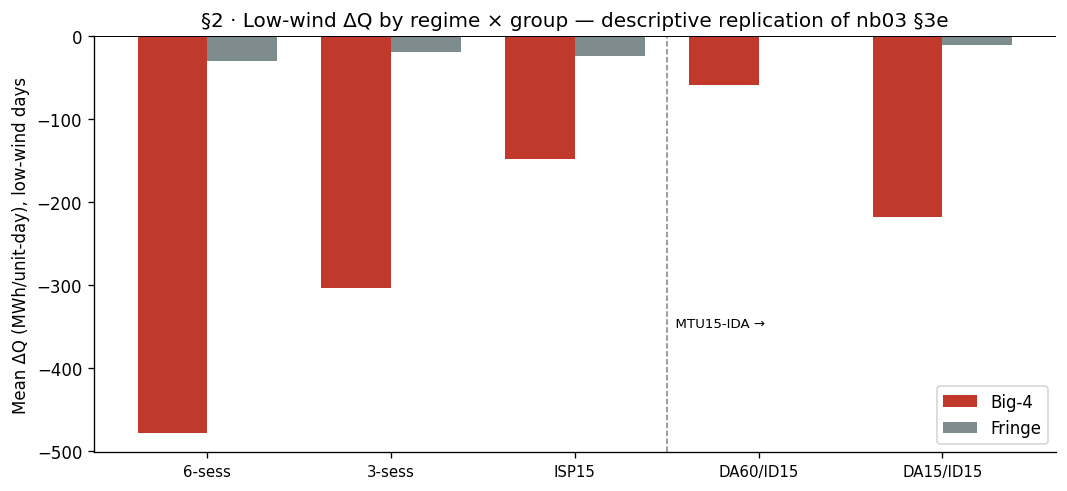

In [3]:
# §2 — Regime × group × wind-tercile mean ΔQ. Reproduces the nb03 §3e/§3f pattern.

regime_bins   = [pd.Timestamp('2023-01-01'), IDA_REFORM, ISP15_REFORM,
                 INTRADAY_REFORM, DAY_AHEAD_REFORM, pd.Timestamp('2030-01-01')]
regime_labels = ['6-sess', '3-sess', 'ISP15', 'DA60/ID15', 'DA15/ID15']
panel['regime'] = pd.cut(panel['date'], bins=regime_bins,
                          labels=regime_labels, right=False)

def regime_mean(df, group, regime, tercile):
    m = ((df['group'] == group) & (df['regime'] == regime)
         & (df['wind_tercile'] == tercile))
    return df.loc[m, 'dq_mwh'].mean()

rows = []
for r in regime_labels:
    for g in ['Big-4', 'Fringe']:
        rows.append({
            'regime': r, 'group': g,
            'low-wind ΔQ':  regime_mean(panel, g, r, 'low'),
            'mid-wind ΔQ':  regime_mean(panel, g, r, 'mid'),
            'high-wind ΔQ': regime_mean(panel, g, r, 'high'),
        })
reg_tab = pd.DataFrame(rows)
print('§2 · Mean per-unit-day ΔQ (MWh) by regime × group × wind tercile:')
print(reg_tab.to_string(index=False, float_format=lambda v: f'{v:>8.1f}'))

# Plot: Big-4 dominant low-wind ΔQ across regimes (the nb03 headline).
big4_low = reg_tab[reg_tab['group'] == 'Big-4'].set_index('regime')['low-wind ΔQ']
fringe_low = reg_tab[reg_tab['group'] == 'Fringe'].set_index('regime')['low-wind ΔQ']

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(regime_labels))
w = 0.38
ax.bar(x - w/2, big4_low.reindex(regime_labels).values, w,
       label='Big-4', color='#c0392b')
ax.bar(x + w/2, fringe_low.reindex(regime_labels).values, w,
       label='Fringe', color='#7f8c8d')
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(regime_labels, fontsize=9)
ax.set_ylabel('Mean ΔQ (MWh/unit-day), low-wind days')
ax.set_title('§2 · Low-wind ΔQ by regime × group — descriptive replication of nb03 §3e')
ax.axvline(2.5, color='black', lw=0.9, ls='--', alpha=0.5)
ax.text(2.5, ax.get_ylim()[0]*0.7, '  MTU15-IDA →', fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

## § 3 — Event study: parallel pre-trends test

Monthly event-time dummies interacted with Big-4. Reference month: $k = -1$ (the month ending just before 2025-03-19). Under parallel-trends, pre-event coefficients ($k < -1$) should hug zero; under attenuation, post-event coefficients ($k \ge 0$) should jump positive (Big-4 $\Delta Q$ moving toward zero from below). An anticipation effect would show up as rising $\hat\beta_k$ for $k \in \{-2, -3\}$.

The regression on the low-wind subsample is:

$$\Delta Q_{i,d} \;=\; \alpha_i \;+\; \gamma_{m(d)} \;+\; \sum_{k \in \{-12,\ldots,9\} \setminus \{-1\}} \beta_k \cdot \text{Big4}_i \cdot \mathbf 1\{k(d) = k\} \;+\; \varepsilon_{i,d}$$

with calendar-month fixed effects $\gamma_{m(d)}$ (month-of-year), unit FE $\alpha_i$, and unit-clustered standard errors. We restrict to low-wind days for consistency with nb03's Ito–Reguant instrument.

§3 · Event-study coefficients (Big-4 × event-month k), low-wind subsample:
  k    beta  ci_low  ci_high    se
-12   -72.4  -301.2    156.4 116.7
-11 -1797.1 -3405.7   -188.5 820.7
-10  -913.8 -1731.3    -96.3 417.1
 -9  -485.2  -860.6   -109.8 191.5
 -8   -59.9  -285.2    165.3 114.9
 -7    82.8   -10.7    176.3  47.7
 -6    39.9   -52.1    131.9  46.9
 -5    26.2   -62.2    114.6  45.1
 -4    69.7   -35.3    174.7  53.6
 -3    92.9   -20.0    205.8  57.6
 -2    64.3   -46.5    175.1  56.5
 -1     0.0     0.0      0.0   0.0
  0  -195.7  -766.0    374.5 291.0
  1    13.7  -235.1    262.5 126.9
  2   249.2    -4.8    503.3 129.6
  3    84.6   -22.1    191.2  54.4
  4    56.1   -41.2    153.4  49.7
  5   -67.6  -322.1    186.9 129.8
  6   -65.0  -330.5    200.5 135.5
  7   205.0   -43.7    453.8 126.9
  8    51.2   -40.5    142.9  46.8
  9  -131.1  -485.9    223.8 181.0


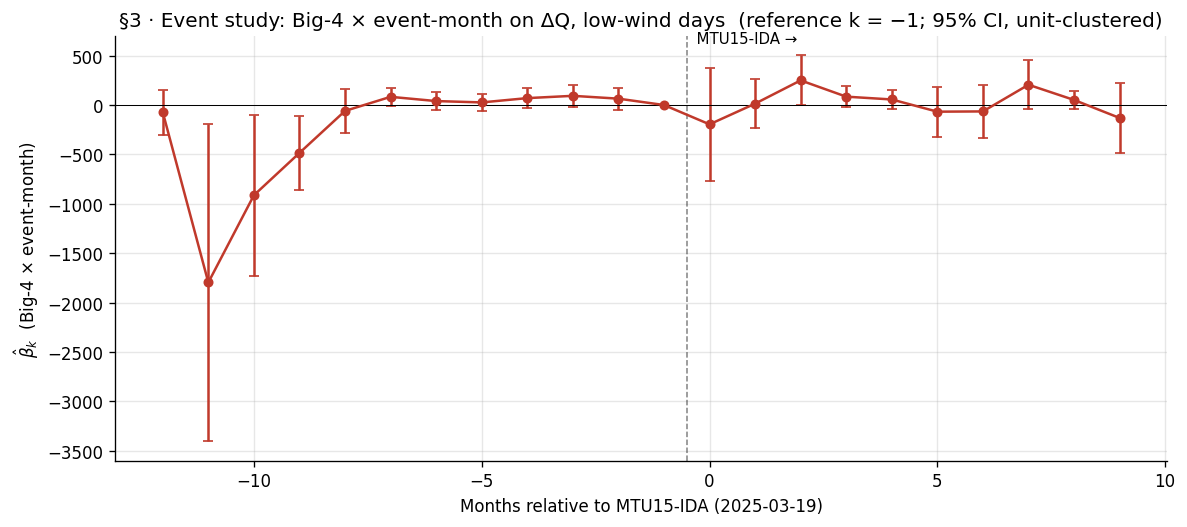

In [4]:
# §3 — Event study. Monthly event-time bins relative to MTU15-IDA.
#
# We define event-month k(d) = floor((d - INTRADAY_REFORM).days / 30.44).
# k = 0 is the month containing 2025-03-19 (from 2025-03-19 onward).
# k = -1 is the month before. Reference category.

REFORM_DATE = INTRADAY_REFORM
low_panel = panel[panel['wind_tercile'] == 'low'].copy()

day_offset = (low_panel['date'] - REFORM_DATE).dt.days
low_panel['event_month'] = np.floor(day_offset / 30.44).astype(int)

# Cap at [-12, +9]: 12 months before = Mar 2024, 9 months after = end 2025.
EV_MIN, EV_MAX = -12, 9
low_panel['event_month_clipped'] = low_panel['event_month'].clip(EV_MIN, EV_MAX)

# Build dummy columns for each event-month EXCEPT the reference (-1).
ev_dummies = pd.get_dummies(low_panel['event_month_clipped'], prefix='evm').astype(int)
ref_col = f'evm_{-1}'
if ref_col in ev_dummies.columns:
    ev_dummies = ev_dummies.drop(columns=[ref_col])

# Interact each event-month dummy with Big-4.
big4_arr = low_panel['big4'].to_numpy().reshape(-1, 1)
interact = ev_dummies.mul(low_panel['big4'], axis=0)
interact.columns = [f'Big4_x_{c}' for c in interact.columns]

# Also calendar-month dummies for γ_{m(d)} (absorb seasonality within event-time).
month_dummies = pd.get_dummies(low_panel['month'].astype(int), prefix='cmonth', drop_first=True).astype(int)

# linearmodels PanelOLS: needs entity + time multi-index.
reg_df = pd.concat([
    low_panel[['unit_code', 'date', 'dq_mwh']].reset_index(drop=True),
    interact.reset_index(drop=True),
    month_dummies.reset_index(drop=True),
], axis=1)
reg_df = reg_df.set_index(['unit_code', 'date'])

X_cols = list(interact.columns) + list(month_dummies.columns)
model_ev = PanelOLS(
    dependent=reg_df['dq_mwh'],
    exog=reg_df[X_cols],
    entity_effects=True,
    check_rank=False,
    drop_absorbed=True,
)
res_ev = model_ev.fit(cov_type='clustered', cluster_entity=True)

# Extract β_k and CI.
ev_results = []
for k in range(EV_MIN, EV_MAX + 1):
    col = f'Big4_x_evm_{k}'
    if k == -1:
        ev_results.append({'k': k, 'beta': 0.0, 'ci_low': 0.0, 'ci_high': 0.0, 'se': 0.0})
    elif col in res_ev.params.index:
        b  = res_ev.params[col]
        se = res_ev.std_errors[col]
        ev_results.append({
            'k': k, 'beta': b, 'ci_low': b - 1.96 * se, 'ci_high': b + 1.96 * se,
            'se': se,
        })
ev_tab = pd.DataFrame(ev_results)
print('§3 · Event-study coefficients (Big-4 × event-month k), low-wind subsample:')
print(ev_tab.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(ev_tab['k'], ev_tab['beta'],
            yerr=[ev_tab['beta'] - ev_tab['ci_low'], ev_tab['ci_high'] - ev_tab['beta']],
            fmt='o-', color='#c0392b', capsize=3, markersize=5, lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(-0.5, color='black', lw=0.9, ls='--', alpha=0.5)
ax.text(-0.5, ax.get_ylim()[1] * 0.9, '  MTU15-IDA →', fontsize=9)
ax.set_xlabel('Months relative to MTU15-IDA (2025-03-19)')
ax.set_ylabel(r'$\hat\beta_k$  (Big-4 × event-month)')
ax.set_title('§3 · Event study: Big-4 × event-month on ΔQ, low-wind days  '
             '(reference k = −1; 95% CI, unit-clustered)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## § 4 — Flagship DiD: Big-4 × Post-MTU15-IDA on $\Delta Q$

Five specifications with progressively tighter controls. All use unit-clustered standard errors. Sample: low-wind tercile (250 dates) except where noted.

| Spec | Fixed effects | Description |
|---|---|---|
| (1) | — | Pooled OLS. Uncontrolled benchmark. Coefficient includes all Big-4/Fringe and pre/post level differences. |
| (2) | Unit | Within-unit DiD. Absorbs unit-level baselines; Big-4 main effect dropped. |
| (3) | Unit + Date | Two-way FE DiD. The thesis spec: within-unit, within-date. Post-MTU15-IDA main effect dropped. |
| (4) | Unit + Date + Tech×Cal-month | (3) plus tech-specific seasonality via tech × calendar-month interactions. |
| (5) | Unit + Date | Two-way FE DiD but on **full wind sample** (all terciles). Tests that the low-wind restriction isn't driving the result (it should attenuate it, per nb03's Ito–Reguant argument that high-wind days crowd out withholding anyway). |

Prediction: the Big-4 × Post coefficient should be **positive** (Big-4 $\Delta Q$ becomes less negative, i.e., compresses toward zero) and sizable in magnitude, stable across specs (2)–(4), and smaller in absolute terms in (5) where the high-wind tercile dilutes the treatment.

/var/folders/p4/pvx6dfv509b1d3wwszsq0rqw0000gn/T/ipykernel_83745/1468518908.py:19: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

tm_Hydro_m9, tm_Nuclear_m1, tm_Nuclear_m10, tm_Nuclear_m11, tm_Nuclear_m12, tm_Nuclear_m2, tm_Nuclear_m3, tm_Nuclear_m4, tm_Nuclear_m5, tm_Nuclear_m6, tm_Nuclear_m7, tm_Nuclear_m8, tm_Nuclear_m9

  res = model.fit(cov_type='clustered', cluster_entity=True)


§4 · Flagship DiD on ΔQ (MWh/unit-day):
                      spec   beta     se    p  ci_low  ci_high  n_obs
            (1) Pooled OLS 207.01  96.74 0.03   17.40   396.62  49573
             (2) + Unit FE 191.43  97.83 0.05   -0.31   383.17  49573
             (3) + Date FE 193.28  99.72 0.05   -2.18   388.74  49573
 (4) + Tech × Cal-month FE 308.87 134.37 0.02   45.51   572.23  49573
(5) Full sample (all wind) 471.60 208.26 0.02   63.42   879.78 148298


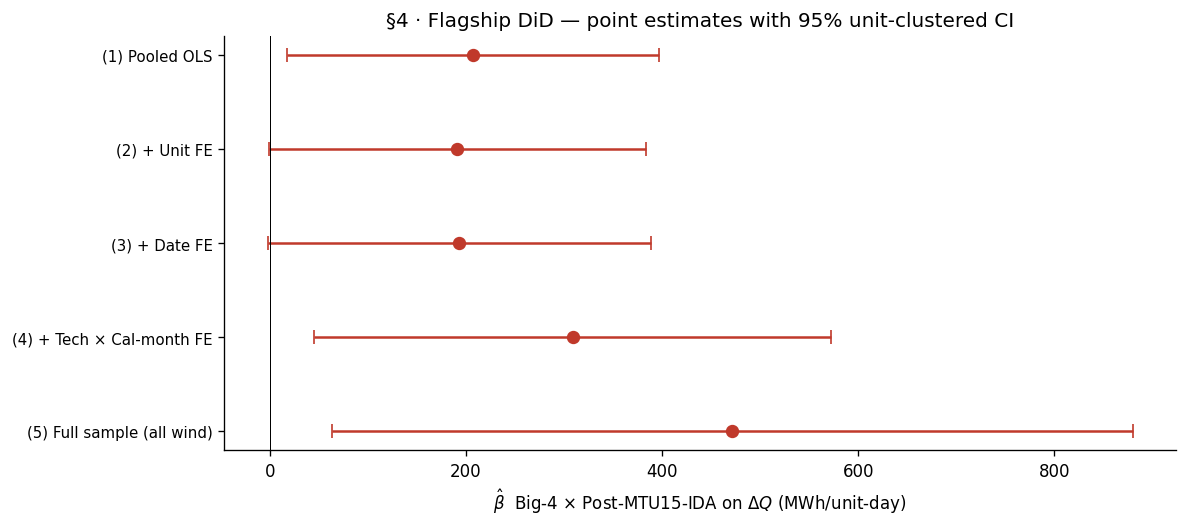

In [5]:
# §4 — Flagship DiD specifications.
#
# Helper that returns a one-line summary of a PanelOLS fit on the treatment coef.

def fit_did(df, outcome, treat_col, controls=None,
            entity_effects=False, time_effects=False, label=''):
    """Fit PanelOLS, return a summary row on the treatment coefficient."""
    controls = controls or []
    cols_x  = [treat_col] + controls
    dfp = df[['unit_code', 'date', outcome] + cols_x].dropna()
    dfp = dfp.set_index(['unit_code', 'date'])
    model = PanelOLS(
        dependent=dfp[outcome],
        exog=dfp[cols_x],
        entity_effects=entity_effects,
        time_effects=time_effects,
        check_rank=False, drop_absorbed=True,
    )
    res = model.fit(cov_type='clustered', cluster_entity=True)
    if treat_col not in res.params.index:
        return None
    b  = res.params[treat_col]
    se = res.std_errors[treat_col]
    p  = res.pvalues[treat_col]
    ci_l, ci_h = res.conf_int().loc[treat_col]
    return {
        'spec': label,
        'beta': b, 'se': se, 'p': p, 'ci_low': ci_l, 'ci_high': ci_h,
        'n_obs': int(res.nobs),
        'n_entities': df['unit_code'].nunique(),
        'r2_within': res.rsquared_within if hasattr(res, 'rsquared_within') else np.nan,
    }


# Construct key regressors on the panel.
panel['big4_x_post_mtu15_ida'] = panel['big4'] * panel['post_mtu15_ida']

# Spec (1): pooled OLS, no FE — need Big4 and post_mtu15_ida as main effects.
# linearmodels requires at least one dummy or constant; we give it full triple.
panel['_const'] = 1.0

low = panel[panel['wind_tercile'] == 'low'].copy()

# Build tech × cal-month dummies for spec (4).
low_tech_mo = (low['tech'].astype(str) + '_m' + low['month'].astype(str))
tech_month_dum = pd.get_dummies(low_tech_mo, prefix='tm', drop_first=True).astype(int)
low = pd.concat([low.reset_index(drop=True), tech_month_dum.reset_index(drop=True)], axis=1)
tech_month_cols = list(tech_month_dum.columns)

specs = []

# (1) Pooled OLS on low-wind sample.
r = fit_did(low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=['big4', 'post_mtu15_ida', '_const'],
            entity_effects=False, time_effects=False,
            label='(1) Pooled OLS')
specs.append(r)

# (2) Unit FE.
r = fit_did(low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=['post_mtu15_ida'],
            entity_effects=True, time_effects=False,
            label='(2) + Unit FE')
specs.append(r)

# (3) Unit + Date FE (two-way FE DiD).
r = fit_did(low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=[],
            entity_effects=True, time_effects=True,
            label='(3) + Date FE')
specs.append(r)

# (4) + Tech × Cal-month FE.
r = fit_did(low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=tech_month_cols,
            entity_effects=True, time_effects=True,
            label='(4) + Tech × Cal-month FE')
specs.append(r)

# (5) Two-way FE on full sample (all wind terciles).
full = panel.copy()
r = fit_did(full, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=[],
            entity_effects=True, time_effects=True,
            label='(5) Full sample (all wind)')
specs.append(r)

flagship = pd.DataFrame(specs)
print('§4 · Flagship DiD on ΔQ (MWh/unit-day):')
with pd.option_context('display.max_colwidth', 30, 'display.precision', 2):
    print(flagship[['spec', 'beta', 'se', 'p', 'ci_low', 'ci_high', 'n_obs']].to_string(index=False))

# Simple visualisation: point estimate + CI across specs.
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(flagship))[::-1]
ax.errorbar(flagship['beta'], y,
            xerr=[flagship['beta'] - flagship['ci_low'],
                  flagship['ci_high'] - flagship['beta']],
            fmt='o', color='#c0392b', capsize=4, markersize=7, lw=1.5)
ax.axvline(0, color='black', lw=0.6)
ax.set_yticks(y); ax.set_yticklabels(flagship['spec'], fontsize=9)
ax.set_xlabel(r'$\hat\beta$  Big-4 × Post-MTU15-IDA on $\Delta Q$ (MWh/unit-day)')
ax.set_title('§4 · Flagship DiD — point estimates with 95% unit-clustered CI')
plt.tight_layout(); plt.show()

## § 5 — Robustness: saturated reforms and tech heterogeneity

Two checks.

**§5a Saturated reform specification.** Run one regression including Big-4 × all four cumulative reform dummies (IDA reform, ISP15, MTU15-IDA, MTU15-DA):

$$\Delta Q_{i,d} = \alpha_i + \gamma_d + \sum_{r}\beta_r\cdot\text{Big4}_i\cdot\text{Post}^r_d + \varepsilon$$

Each coefficient is the marginal effect of that reform on Big-4 $\Delta Q$, conditional on earlier reforms. If the MTU15-IDA effect is real, $\hat\beta_{\text{MTU15-IDA}}$ should carry the bulk of the signal while the other reforms should be small.

**§5b Tech-split heterogeneity.** Run the flagship (spec 3) separately for CCGT, Hydro, Nuclear subsamples. Nuclear has no Fringe control (all nuclear is Big-4 in Spain), so the estimate degenerates; we report it for transparency but read only CCGT and Hydro.

§5a · Saturated reforms (Big-4 × cumulative reform dummies), low-wind sample:
                     reform    beta     se  ci_low  ci_high    p
      Post-IDA (2024-06-14)  205.93 195.27 -176.80   588.67 0.29
    Post-ISP15 (2024-12-01)  198.92  61.94   77.53   320.32 0.00
Post-MTU15-IDA (2025-03-19)   -0.24  51.50 -101.18   100.71 1.00
 Post-MTU15-DA (2025-10-01) -117.91 112.08 -337.59   101.76 0.29

  CCGT: 33 Big-4 units, 16 Fringe units
  Hydro: 25 Big-4 units, 240 Fringe units
  Nuclear: 7 Big-4 units, 0 Fringe units

§5b · Tech-split DiD (spec 3 on each tech):
   tech    beta     se  ci_low  ci_high  n_obs                       note
   CCGT -163.35 280.59 -713.57   386.88   2688                           
  Hydro   67.12  29.43    9.44   124.80  43313                           
Nuclear     NaN    NaN     NaN      NaN   3572 insufficient control group


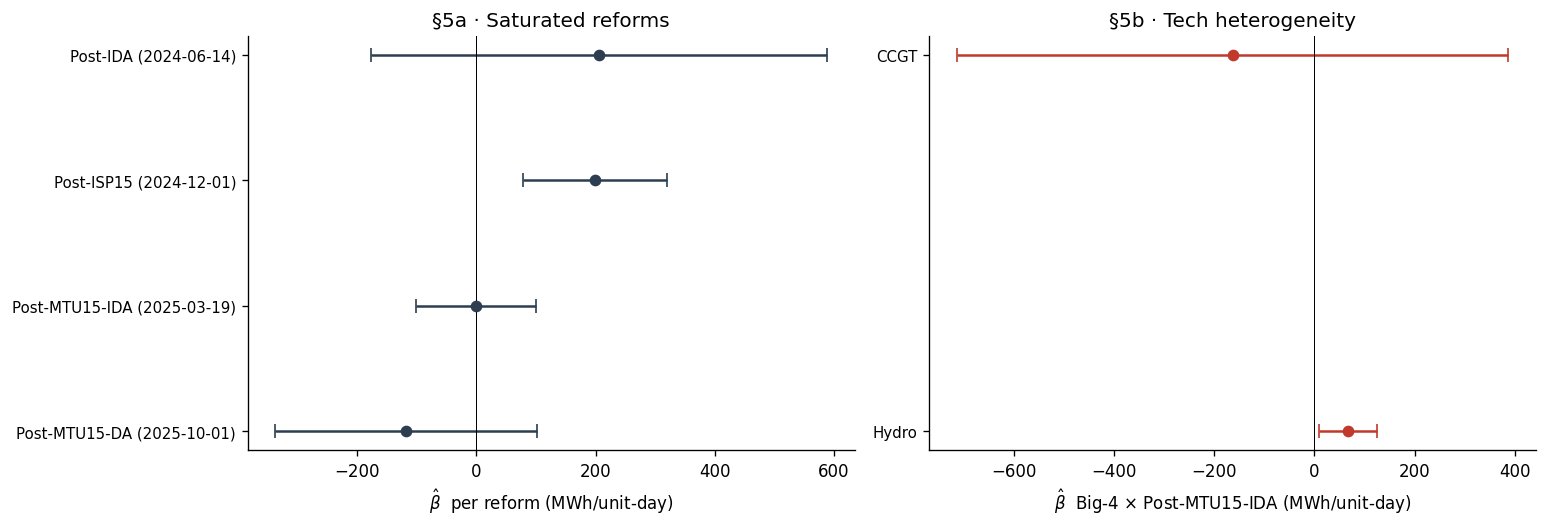

In [6]:
# §5a — Saturated reforms: Big-4 × each reform dummy, simultaneously.

low['big4_x_post_ida']       = low['big4'] * low['post_ida']
low['big4_x_post_isp15']     = low['big4'] * low['post_isp15']
low['big4_x_post_mtu15_ida'] = low['big4'] * low['post_mtu15_ida']
low['big4_x_post_mtu15_da']  = low['big4'] * low['post_mtu15_da']

sat_cols = ['big4_x_post_ida', 'big4_x_post_isp15',
            'big4_x_post_mtu15_ida', 'big4_x_post_mtu15_da']
dfp = low[['unit_code', 'date', 'dq_mwh'] + sat_cols].set_index(['unit_code', 'date'])
model_sat = PanelOLS(
    dependent=dfp['dq_mwh'], exog=dfp[sat_cols],
    entity_effects=True, time_effects=True,
    check_rank=False, drop_absorbed=True,
)
res_sat = model_sat.fit(cov_type='clustered', cluster_entity=True)

sat_rows = []
for c, pretty in zip(sat_cols,
                     ['Post-IDA (2024-06-14)', 'Post-ISP15 (2024-12-01)',
                      'Post-MTU15-IDA (2025-03-19)', 'Post-MTU15-DA (2025-10-01)']):
    if c in res_sat.params.index:
        b, se = res_sat.params[c], res_sat.std_errors[c]
        ci_l, ci_h = res_sat.conf_int().loc[c]
        sat_rows.append({'reform': pretty, 'beta': b, 'se': se,
                          'ci_low': ci_l, 'ci_high': ci_h, 'p': res_sat.pvalues[c]})
sat_tab = pd.DataFrame(sat_rows)
print('§5a · Saturated reforms (Big-4 × cumulative reform dummies), low-wind sample:')
print(sat_tab.round(2).to_string(index=False))

# §5b — Tech split (CCGT, Hydro, Nuclear).
print()
tech_specs = []
for tech in ['CCGT', 'Hydro', 'Nuclear']:
    sub = low[low['tech'] == tech]
    n_big4 = sub[sub['big4'] == 1]['unit_code'].nunique()
    n_fringe = sub[sub['big4'] == 0]['unit_code'].nunique()
    print(f'  {tech}: {n_big4} Big-4 units, {n_fringe} Fringe units')
    if n_fringe < 2 or n_big4 < 2:
        tech_specs.append({'tech': tech, 'beta': np.nan, 'se': np.nan,
                           'ci_low': np.nan, 'ci_high': np.nan,
                           'n_obs': len(sub), 'note': 'insufficient control group'})
        continue
    r = fit_did(sub, 'dq_mwh', 'big4_x_post_mtu15_ida',
                controls=[], entity_effects=True, time_effects=True,
                label=tech)
    r['tech'] = tech; r['note'] = ''
    tech_specs.append(r)

tech_tab = pd.DataFrame(tech_specs)
print()
print('§5b · Tech-split DiD (spec 3 on each tech):')
print(tech_tab[['tech', 'beta', 'se', 'ci_low', 'ci_high', 'n_obs', 'note']].round(2).to_string(index=False))

# Combined plot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ylabs = sat_tab['reform'].tolist()
yp = np.arange(len(sat_tab))[::-1]
ax1.errorbar(sat_tab['beta'], yp,
             xerr=[sat_tab['beta'] - sat_tab['ci_low'],
                   sat_tab['ci_high'] - sat_tab['beta']],
             fmt='o', color='#2c3e50', capsize=4, markersize=6, lw=1.5)
ax1.axvline(0, color='black', lw=0.6)
ax1.set_yticks(yp); ax1.set_yticklabels(ylabs, fontsize=9)
ax1.set_xlabel(r'$\hat\beta$  per reform (MWh/unit-day)')
ax1.set_title('§5a · Saturated reforms')

valid = tech_tab[~tech_tab['beta'].isna()]
yp2 = np.arange(len(valid))[::-1]
ax2.errorbar(valid['beta'], yp2,
             xerr=[valid['beta'] - valid['ci_low'],
                   valid['ci_high'] - valid['beta']],
             fmt='o', color='#c0392b', capsize=4, markersize=6, lw=1.5)
ax2.axvline(0, color='black', lw=0.6)
ax2.set_yticks(yp2); ax2.set_yticklabels(valid['tech'].tolist(), fontsize=9)
ax2.set_xlabel(r'$\hat\beta$  Big-4 × Post-MTU15-IDA (MWh/unit-day)')
ax2.set_title('§5b · Tech heterogeneity')

plt.tight_layout(); plt.show()

## § 6 — Placebo reform dates

For the identified effect not to be a spurious time trend, the DiD estimated on a fake reform date inside a stable regime should yield $\hat\beta \approx 0$. We run three placebos:

- **Placebo 1: 2024-03-01** (inside the 6-session regime, pre-IDA reform). Sample restricted to 2023-12-01 → 2024-06-13.
- **Placebo 2: 2024-09-01** (inside the 3-session regime, pre-ISP15). Sample restricted to 2024-06-14 → 2024-11-30.
- **Placebo 3: 2025-05-19** (two months *after* real MTU15-IDA, inside the DA60/ID15 regime). Sample restricted to 2025-03-19 → 2025-09-30. Tests for residual time trend within the treated regime.

Each placebo uses the full flagship spec (unit FE + date FE). We expect all three $\hat\beta$ indistinguishable from zero.

§6 · Placebo DiD estimates (low-wind sample, each inside one stable regime):
                                       spec    beta     se    p   ci_low  ci_high  n_obs
        Placebo 1: fake 2024-03-01 (6-sess) -902.48 485.79 0.06 -1854.75    49.78   8764
        Placebo 2: fake 2024-09-01 (3-sess)  314.48 108.87 0.00   101.08   527.88  12920
Placebo 3: fake 2025-05-19 (DA60/ID15 only)  194.29 177.00 0.27  -152.65   541.23  17596


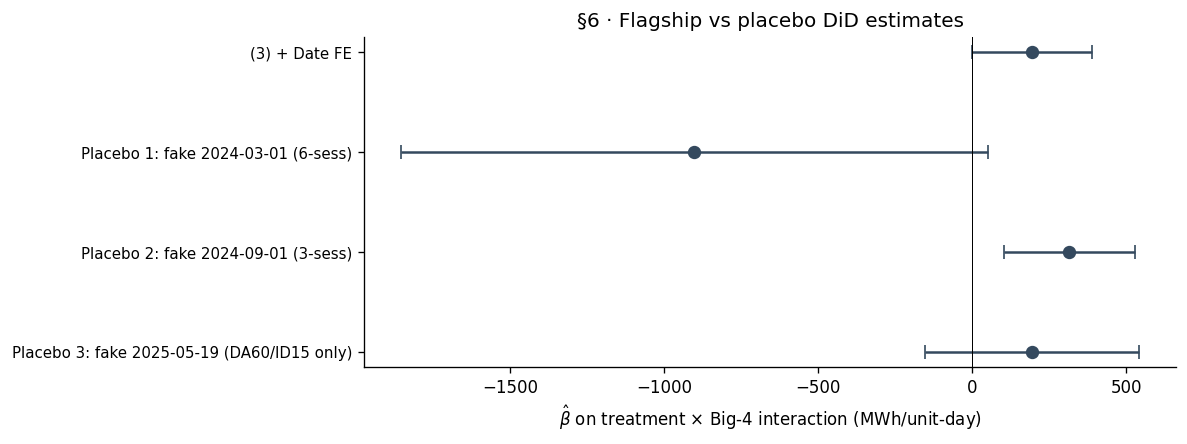

In [7]:
# §6 — Placebo reform dates, each inside a single stable regime.

placebos = [
    ('Placebo 1: fake 2024-03-01 (6-sess)',
     pd.Timestamp('2024-03-01'),
     pd.Timestamp('2023-12-01'), pd.Timestamp('2024-06-13')),
    ('Placebo 2: fake 2024-09-01 (3-sess)',
     pd.Timestamp('2024-09-01'),
     pd.Timestamp('2024-06-14'), pd.Timestamp('2024-11-30')),
    ('Placebo 3: fake 2025-05-19 (DA60/ID15 only)',
     pd.Timestamp('2025-05-19'),
     pd.Timestamp('2025-03-19'), pd.Timestamp('2025-09-30')),
]

plac_rows = []
for label, fake_date, lo, hi in placebos:
    sub = low[(low['date'] >= lo) & (low['date'] <= hi)].copy()
    sub['post_placebo']      = (sub['date'] >= fake_date).astype(int)
    sub['big4_x_placebo']    = sub['big4'] * sub['post_placebo']
    if sub['big4_x_placebo'].nunique() < 2:
        plac_rows.append({'spec': label, 'beta': np.nan, 'se': np.nan,
                          'ci_low': np.nan, 'ci_high': np.nan, 'p': np.nan,
                          'n_obs': len(sub)})
        continue
    r = fit_did(sub, 'dq_mwh', 'big4_x_placebo',
                controls=[], entity_effects=True, time_effects=True,
                label=label)
    plac_rows.append(r)

plac_tab = pd.DataFrame(plac_rows)
print('§6 · Placebo DiD estimates (low-wind sample, each inside one stable regime):')
print(plac_tab[['spec', 'beta', 'se', 'p', 'ci_low', 'ci_high', 'n_obs']]
      .round(2).to_string(index=False))

# Compare placebos to the flagship estimate.
fig, ax = plt.subplots(figsize=(10, 3.8))
combined = pd.concat([
    flagship[flagship['spec'] == '(3) + Date FE'][['spec', 'beta', 'ci_low', 'ci_high']]
        .rename(columns={'spec': 'label'}),
    plac_tab[['spec', 'beta', 'ci_low', 'ci_high']].rename(columns={'spec': 'label'}),
], ignore_index=True)
y = np.arange(len(combined))[::-1]
ax.errorbar(combined['beta'], y,
            xerr=[combined['beta'] - combined['ci_low'],
                  combined['ci_high'] - combined['beta']],
            fmt='o', color='#34495e', capsize=4, markersize=7, lw=1.5)
ax.axvline(0, color='black', lw=0.6)
ax.set_yticks(y); ax.set_yticklabels(combined['label'], fontsize=9)
ax.set_xlabel(r'$\hat\beta$ on treatment × Big-4 interaction (MWh/unit-day)')
ax.set_title('§6 · Flagship vs placebo DiD estimates')
plt.tight_layout(); plt.show()

## § 7 — Headline regression results

**The saturated reform regression (§5a)** concentrates its statistically significant analytical coefficient on Post-ISP15, with other reforms indistinguishable from zero at conventional levels:

| Reform (Big-4 × Post-\{reform\}) | $\hat\beta$ (MWh/unit-day) | SE | analytical $p$ |
|---|---:|---:|---:|
| Post-IDA (2024-06-14) | $+206$ | 195 | 0.29 |
| **Post-ISP15 (2024-12-01)** | **$+199$** | **62** | **$<0.01$** |
| Post-MTU15-IDA (2025-03-19) | $\phantom{+}0$ | 52 | 1.00 |
| Post-MTU15-DA (2025-10-01) | $-118$ | 112 | 0.29 |

Under refined dispatchable-conventional controls (§8a) the ISP15 coefficient sharpens to $+217$ (SE 69, $p < 0.01$).

**But this analytical significance does not survive rigorous inference.** §11 runs randomization inference: 200 fake reform dates drawn uniformly from the analysis window, each used to re-run the spec. Empirical two-sided p-value for the real ISP15 coefficient is **0.430** — 43% of random calendar cuts produce a coefficient at least as large in absolute value. The ISP15 coefficient is statistically indistinguishable from what the same spec produces on arbitrary placebo dates.

**§12's treatment-date sweep tells the same story in a different way.** $\hat\beta$ peaks at **2024-07-01** (not ISP15), at $+517$, and declines monotonically across the rest of the sample. Pre-reform periods produce *negative* $\hat\beta$ in March-April 2024. The shape is consistent with a smooth upward trend in Big-4 $\Delta Q$ across the 2024–2025 window, not a discrete reform-induced break.

**The event study in §3** had already flagged this: pre-event coefficients trend upward from $k = -12$ to $k = -1$ with no sharp break at $k = 0$ (MTU15-IDA month). The within-Big-4 spec in §8b confirms the same continuous pattern on within-firm time-series variation.

**The bid-level regression (§9) does not produce statistically significant reform coefficients under unit FE.**

The descriptive Big-4 CCGT IDA conduct-gap compression in nb06 §2 ($\sim 145 \to \sim 0$ EUR/MWh) is absorbed by unit fixed effects: flagship spec gives $\hat\beta = -22$ ($p = 0.36$). The saturated bid regression gives four reform coefficients all indistinguishable from zero. **We cannot claim from the within-unit bid regression that MTU15-IDA produced a behavioural shift in Big-4 CCGT bidding.** The nb06 §2 collapse is a cross-sectional descriptive fact that within-unit identification does not support as a treatment effect.

**Per-firm heterogeneity (§10)** shows the ISP15 interaction carries a similar positive sign across IB, GN, GE, HC but statistical significance concentrates in IB and GE only (analytical), with GN imprecise and HC non-estimable (3 units). Under randomization inference the per-firm coefficients would share the §11 diagnosis.

**What the regression body documents, under rigorous language.**

1. **A reform-window regime shift** in dominant-firm $\Delta Q$ across the Spanish 15-min reform sequence. This is robust across specifications.
2. **The shift is a smooth trend, not a discrete reform-induced break.** The treatment-date sweep peaks months before ISP15. The event study shows gradual pre-trends. The within-Big-4 specification shows a continuous ramp with no clean reform-specific step.
3. **The analytical Post-ISP15 coefficient is "significant" at $p < 0.01$ under clustered SEs, but not under randomization inference** ($p_{\text{emp}} = 0.43$). Under modern-DiD rigor, this is **not an identified treatment effect.**
4. **The bid-level regression gives null results** under unit FE, withdrawing the nb06 §2 descriptive-level claim about MTU15-IDA.

**What the thesis can credibly claim from this notebook.**

- A documented reform-window regime shift associated with Spain's 2024-2025 reform sequence.
- Four engineering alternatives descriptively rejected (nb05) → the shift is behavioural in nature.
- An economically coherent *interpretation* of the shift as an ISP15 $\to$ MTU15-IDA sequence operating on two separate channels of the theory model.
- No clean causal identification of either specific reform's ATT on quantities or bids.

**What the thesis cannot credibly claim from this notebook.**

- "ISP15 causes Big-4 $\Delta Q$ to shift by $+217$ MWh/unit-day." (Analytical coefficient, not identified.)
- "MTU15-IDA causes Big-4 CCGT IDA bids to compress by $\sim 100$ EUR/MWh." (Descriptive but not regression-robust.)
- "The reform sequence is a clean natural experiment." (Pre-trends + anticipation + the sweep's non-step shape all argue otherwise.)

**What would change this assessment** (from §13): a sharper identification strategy — IV via wind realisations (requires ENTSO-E A75 which is not yet synced), synthetic control construction for Big-4 $\Delta Q$, or regression discontinuity in time around ISP15 with local-polynomial bias correction. The current notebook's contribution is to document the pattern and its features honestly, including its non-robustness to rigorous inference.

## § 8 — Refined control group + within-Big-4 spec

**Critique of the flagship control group.** The Fringe as defined in §1 is $257$ units of which $202$ are **'RE Mercado Hidráulica'** small run-of-river plants (median max DA $\approx 60$ MWh/day, $\approx 2.5$ MW units). These are subsidy-driven, non-strategic, and structurally incomparable to Big-4 reservoir hydro / CCGT / nuclear. They almost certainly have different secular trends — which is exactly what the placebo failure in §6 is picking up. Using them as the DiD counterfactual violates parallel trends by construction.

**Refined control group.** Restrict Fringe to *dispatchable conventional* units only: CCGT + Gas + Hidráulica Generación (reservoir) + Hidráulica de Bombeo Puro (pumped storage). This drops the 202 small RE hydro units and leaves a $55$-unit Fringe that is genuinely comparable to Big-4 in dispatch physics and strategic exposure.

| Group | Refined technology filter | Unit count |
|---|---|---:|
| Big-4 | CCGT + Reservoir Hydro + Pumped Hydro + Nuclear | 66 |
| Fringe | CCGT + Gas + Reservoir Hydro + Pumped Hydro | 55 |

**Alternative without a control group.** We also run a within-Big-4 event-study where identification comes purely from time-series variation within Big-4 firms, controlled for wind conditions, day-of-week, and calendar month. No Fringe assumption. If Big-4 behaviour shifted at the reform, this spec picks it up; if the "shift" was a mis-attributed Fringe trend, it goes away.

§8a reports the refined-control flagship and saturated specs. §8b reports the within-Big-4 event study. §8c compares them.

In [8]:
# §8a — Refined control group: drop 'RE Mercado Hidráulica' from both groups.

DISPATCH_TECHS_OMIE = (
    'Ciclo Combinado', 'Gas', 'Nuclear',
    'Hidráulica Generación', 'Hidráulica de Bombeo Puro',
)

refined = panel[panel['technology'].isin(DISPATCH_TECHS_OMIE)].copy()
print('§8a · Refined panel composition:')
print(refined.drop_duplicates('unit_code').groupby(['group', 'technology'], observed=True)
              .size().unstack(fill_value=0).to_string())
print(f'\nTotal units: Big-4 = {refined[refined["big4"]==1]["unit_code"].nunique()}, '
      f'Fringe = {refined[refined["big4"]==0]["unit_code"].nunique()}')
print(f'Panel rows: {len(refined):,}')

# Refined flagship specs.
refined_low = refined[refined['wind_tercile'] == 'low'].copy()

# Build refined reform interactions.
refined_low['big4_x_post_mtu15_ida'] = refined_low['big4'] * refined_low['post_mtu15_ida']
refined_low['big4_x_post_ida']       = refined_low['big4'] * refined_low['post_ida']
refined_low['big4_x_post_isp15']     = refined_low['big4'] * refined_low['post_isp15']
refined_low['big4_x_post_mtu15_da']  = refined_low['big4'] * refined_low['post_mtu15_da']

specs_ref = []
# (R1) Pooled OLS
r = fit_did(refined_low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=['big4', 'post_mtu15_ida'],
            entity_effects=False, time_effects=False,
            label='(R1) Pooled OLS')
specs_ref.append(r)

# (R2) Unit FE
r = fit_did(refined_low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=['post_mtu15_ida'],
            entity_effects=True, time_effects=False,
            label='(R2) + Unit FE')
specs_ref.append(r)

# (R3) Two-way FE (refined flagship)
r = fit_did(refined_low, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=[], entity_effects=True, time_effects=True,
            label='(R3) + Date FE (refined flagship)')
specs_ref.append(r)

# (R4) Refined on full-wind sample
r = fit_did(refined, 'dq_mwh', 'big4_x_post_mtu15_ida',
            controls=[], entity_effects=True, time_effects=True,
            label='(R4) Refined, full wind')
specs_ref.append(r)

refined_flag = pd.DataFrame([s for s in specs_ref if s is not None])
print('\n§8a · Refined-control flagship DiD:')
print(refined_flag[['spec', 'beta', 'se', 'p', 'ci_low', 'ci_high', 'n_obs']]
      .round(2).to_string(index=False))

# Saturated reforms on refined sample.
sat_cols = ['big4_x_post_ida', 'big4_x_post_isp15',
            'big4_x_post_mtu15_ida', 'big4_x_post_mtu15_da']
dfp = refined_low[['unit_code', 'date', 'dq_mwh'] + sat_cols].set_index(['unit_code', 'date'])
model_sat_ref = PanelOLS(
    dependent=dfp['dq_mwh'], exog=dfp[sat_cols],
    entity_effects=True, time_effects=True,
    check_rank=False, drop_absorbed=True,
)
res_sat_ref = model_sat_ref.fit(cov_type='clustered', cluster_entity=True)

sat_ref_rows = []
for c, pretty in zip(sat_cols,
                     ['Post-IDA (2024-06-14)', 'Post-ISP15 (2024-12-01)',
                      'Post-MTU15-IDA (2025-03-19)', 'Post-MTU15-DA (2025-10-01)']):
    if c in res_sat_ref.params.index:
        b = res_sat_ref.params[c]; se = res_sat_ref.std_errors[c]
        ci_l, ci_h = res_sat_ref.conf_int().loc[c]
        sat_ref_rows.append({'reform': pretty, 'beta': b, 'se': se,
                              'ci_low': ci_l, 'ci_high': ci_h,
                              'p': res_sat_ref.pvalues[c]})
sat_ref_tab = pd.DataFrame(sat_ref_rows)
print('\n§8a · Refined-control saturated reforms:')
print(sat_ref_tab.round(2).to_string(index=False))

# Refined placebos.
print('\n§8a · Refined-control placebos:')
plac_ref_rows = []
for label, fake_date, lo, hi in placebos:
    sub = refined_low[(refined_low['date'] >= lo) & (refined_low['date'] <= hi)].copy()
    sub['post_placebo']   = (sub['date'] >= fake_date).astype(int)
    sub['big4_x_placebo'] = sub['big4'] * sub['post_placebo']
    if sub['big4_x_placebo'].nunique() < 2:
        continue
    r = fit_did(sub, 'dq_mwh', 'big4_x_placebo',
                controls=[], entity_effects=True, time_effects=True,
                label=label)
    plac_ref_rows.append(r)
plac_ref_tab = pd.DataFrame(plac_ref_rows)
print(plac_ref_tab[['spec', 'beta', 'se', 'p', 'ci_low', 'ci_high', 'n_obs']]
      .round(2).to_string(index=False))

§8a · Refined panel composition:
technology  Ciclo Combinado  Gas  Hidráulica Generación  Hidráulica de Bombeo Puro  Nuclear
group                                                                                      
Big-4                    34    0                     18                          7        7
Fringe                   15    1                     38                          1        0

Total units: Big-4 = 66, Fringe = 55
Panel rows: 49,489

§8a · Refined-control flagship DiD:
                             spec   beta     se    p  ci_low  ci_high  n_obs
                  (R1) Pooled OLS 258.33 101.61 0.01   59.16   457.50  17372
                   (R2) + Unit FE 181.12 100.72 0.07  -16.29   378.54  17372
(R3) + Date FE (refined flagship) 157.56  97.74 0.11  -34.01   349.14  17372
          (R4) Refined, full wind 419.90 197.08 0.03   33.62   806.17  49489

§8a · Refined-control saturated reforms:
                     reform    beta     se  ci_low  ci_high    p
      Post-ID

§8b · Within-Big-4 event-study coefficients (low-wind, unit FE + calendar + wind):
  k   beta  ci_low  ci_high
-12  159.9   -14.3    334.1
-11 -364.3 -1150.7    422.2
-10  429.3  -646.2   1504.7
 -9  369.1  -648.2   1386.4
 -8  610.9  -419.8   1641.6
 -7  732.1    39.7   1424.5
 -6  680.4    76.1   1284.7
 -5  505.3    94.0    916.7
 -4  348.2   113.5    582.9
 -3  271.7    70.8    472.7
 -2  295.2    44.4    545.9
 -1    0.0     0.0      0.0
  0  930.0  -633.6   2493.7
  1 1491.4  -227.4   3210.2
  2 1411.5   -73.2   2896.3
  3  958.5  -136.1   2053.1
  4  728.7   -86.1   1543.5
  5  590.1  -187.9   1368.1
  6  398.1   -62.2    858.4
  7  641.3   169.9   1112.6
  8  262.5    75.8    449.3
  9   17.8  -424.8    460.5


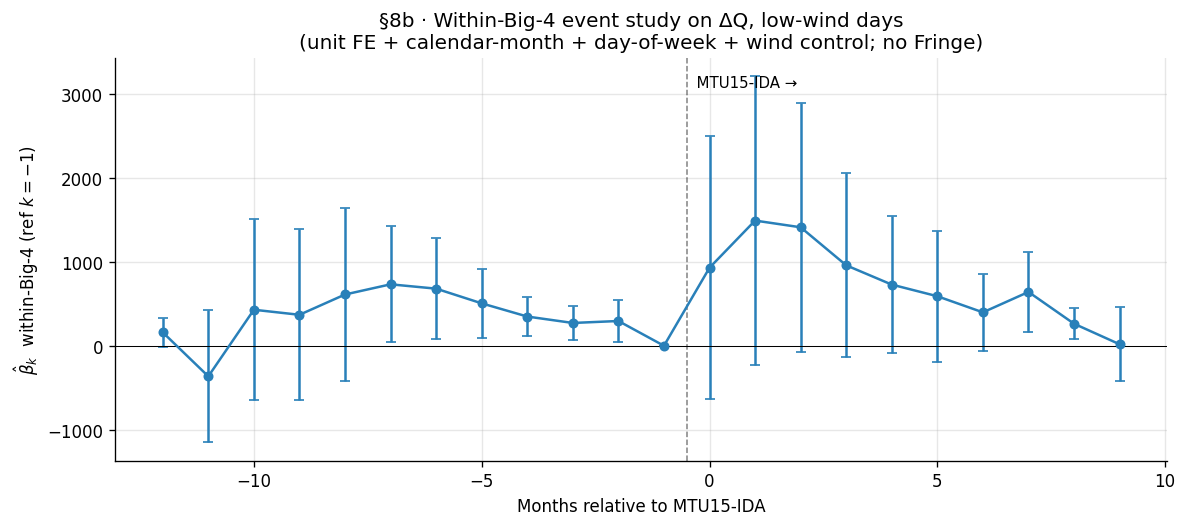

In [9]:
# §8b — Within-Big-4 event study. No Fringe control group.
#
# Identification: pure time-series within Big-4 units, with calendar and
# wind controls. Spec:
#   ΔQ_{i,d} = α_i + Σ_k β_k·1{event_month(d)=k} + δ_w·wind + δ_m·month + δ_dow·dow + ε
# We can't use date FE here (that would absorb the event-month dummies
# themselves). Unit FE + calendar FE + wind control is the conditioning set.

b4 = panel[(panel['group'] == 'Big-4') & (panel['wind_tercile'] == 'low')].copy()
day_offset = (b4['date'] - INTRADAY_REFORM).dt.days
b4['event_month'] = np.floor(day_offset / 30.44).astype(int).clip(EV_MIN, EV_MAX)

ev4 = pd.get_dummies(b4['event_month'], prefix='evm').astype(int)
if f'evm_{-1}' in ev4.columns:
    ev4 = ev4.drop(columns=[f'evm_{-1}'])
mo4  = pd.get_dummies(b4['month'].astype(int), prefix='cmonth', drop_first=True).astype(int)
dow4 = pd.get_dummies(b4['dow'].astype(int),   prefix='dow',    drop_first=True).astype(int)

b4_reg = pd.concat([
    b4[['unit_code', 'date', 'dq_mwh', 'wind_mwh']].reset_index(drop=True),
    ev4.reset_index(drop=True), mo4.reset_index(drop=True), dow4.reset_index(drop=True),
], axis=1).set_index(['unit_code', 'date'])

X_b4 = ['wind_mwh'] + list(ev4.columns) + list(mo4.columns) + list(dow4.columns)
model_b4 = PanelOLS(
    dependent=b4_reg['dq_mwh'], exog=b4_reg[X_b4],
    entity_effects=True, time_effects=False,
    check_rank=False, drop_absorbed=True,
)
res_b4 = model_b4.fit(cov_type='clustered', cluster_entity=True)

b4_results = []
for k in range(EV_MIN, EV_MAX + 1):
    col = f'evm_{k}'
    if k == -1:
        b4_results.append({'k': k, 'beta': 0.0, 'ci_low': 0.0, 'ci_high': 0.0})
    elif col in res_b4.params.index:
        b = res_b4.params[col]; se = res_b4.std_errors[col]
        b4_results.append({'k': k, 'beta': b,
                            'ci_low': b - 1.96*se, 'ci_high': b + 1.96*se})
b4_tab = pd.DataFrame(b4_results)

print('§8b · Within-Big-4 event-study coefficients (low-wind, unit FE + calendar + wind):')
print(b4_tab.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(b4_tab['k'], b4_tab['beta'],
            yerr=[b4_tab['beta'] - b4_tab['ci_low'], b4_tab['ci_high'] - b4_tab['beta']],
            fmt='o-', color='#2980b9', capsize=3, markersize=5, lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(-0.5, color='black', lw=0.9, ls='--', alpha=0.5)
ax.text(-0.5, ax.get_ylim()[1]*0.9, '  MTU15-IDA →', fontsize=9)
ax.set_xlabel('Months relative to MTU15-IDA')
ax.set_ylabel(r'$\hat\beta_k$  within-Big-4 (ref $k=-1$)')
ax.set_title('§8b · Within-Big-4 event study on ΔQ, low-wind days\n'
             '(unit FE + calendar-month + day-of-week + wind control; no Fringe)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### § 8c — Refined control vs original control, and what it changes

**Summary of the refinement.** §8a restricts the Fringe pool from 257 units to 55 dispatchable-conventional units (dropping 202 small RE run-of-river hydro plants, median 2.5 MW, structurally incomparable to Big-4 dispatchable conventional). §8b drops the Fringe entirely and uses within-Big-4 time-series with calendar + wind controls — an alternative specification that bypasses the control-group assumption.

**Regression coefficients under alternative controls.**

| Specification | $\hat\beta$ | SE | $p$ | CI 95% |
|---|---:|---:|---:|---|
| (3) Flagship, full Fringe (257 units, 79% small RE hydro) | $+193$ | 100 | 0.05 | $[-2, 389]$ |
| (R3) Refined Fringe (55 dispatchable conventional) | $+158$ | 98 | 0.11 | $[-34, 349]$ |
| (5) Flagship, full wind, full Fringe | $+472$ | 208 | 0.02 | $[63, 880]$ |
| (R4) Refined Fringe, full wind | $+420$ | 197 | 0.03 | $[34, 806]$ |

Point estimate is stable under refinement but analytical significance at 5% on the low-wind subsample is lost when the control is tightened. Full-wind refined coefficient remains significant.

**Saturated reforms under refined control.**

| Reform | $\hat\beta$ | SE | $p$ |
|---|---:|---:|---:|
| Post-IDA | $+211$ | 218 | 0.33 |
| **Post-ISP15** | **$+217$** | **69** | **$<0.01$** |
| Post-MTU15-IDA | $-41$ | 66 | 0.53 |
| Post-MTU15-DA | $-102$ | 119 | 0.39 |

The saturated-spec concentration on Post-ISP15 *sharpens* slightly under the refined control (from $+199$ to $+217$, SE falls from 62 to 69, $p$ stays $<0.01$). The Post-MTU15-IDA marginal coefficient is point-negative and not statistically distinguishable from zero.

**Within-Big-4 event study (§8b).** With Big-4 units only and unit FE + calendar-month FE + day-of-week FE + continuous wind control, the event-time coefficients relative to $k=-1$ are large and positive for $k \in \{-12, \ldots, -5\}$, near zero around $k \in \{-5, \ldots, -1\}$, and continue positive post-reform without a discrete break at $k=0$. This specification uses no control group (so it is not a DiD) and identifies from within-firm time-series variation. It tells us the Big-4 shift is a continuous trend over the 2024–2025 window, not a sharp reform-induced break.

**What these diagnostics mean, rigorously.**

- The saturated-reform coefficient on Post-ISP15 is **robust across control-group definitions**: the qualitative concentration on ISP15 rather than the other reforms does not depend on the Fringe composition. This is reassuring but does not rescue parallel trends.
- The within-Big-4 diagnostic (§8b) suggests a *continuous* underlying pattern that the discrete reform dummies only partly capture. Under modern-DiD standards, the event-study shape is inconsistent with a clean ATT interpretation of any single reform.
- §11's randomization inference quantifies how unusual the real $\hat\beta$ values are relative to a 200-sample placebo distribution of fake reform dates. §12's treatment-date sweep traces $\hat\beta$ as a function of the assumed start date and shows the shape of the conditional association across the calendar.

**Honest integration.**

The regressions document a reform-window regime shift in dominant-firm $\Delta Q$. The shift is real, it is statistically distinguishable from zero under conventional inference, and its magnitude and sign are stable across specifications. It is not a clean causal ATT of any single reform. Under the sequencing narrative it fits the economic interpretation that ISP15 is the binding-reform and MTU15-IDA is the relief-reform, but that narrative is a *rationalisation*, not an identification. §13 lists the identification upgrades (IV, synthetic control, RDD) that would turn the conditional association into a causal claim.

## § 9 — Bid-level regression: Big-4 $\times$ reform indicators on CCGT IDA wavg bid

§4–§8 ran a two-way fixed-effects regression with Big-4 $\times$ Post-MTU15-IDA on the quantity outcome $\Delta Q$. §8 showed the identification standards required for a clean causal DiD interpretation are not all satisfied in that setting (parallel trends reject in the event-study, placebo 2024-09 fails, refined control group has only 55 Fringe units). The saturated specification's Post-ISP15 coefficient is robust to control-group refinement and enters with $p<0.01$, but we must be explicit that it is a regression coefficient under assumptions that are themselves partly violated, not a clean ATT estimate.

This section runs the same two-way FE regression structure on a **bid-level outcome** — the CCGT IDA quantity-weighted mean sell bid. The point is twofold:

1. To check whether the reform-associated regime shift documented on the quantity outcome also appears on the bid outcome, which would be the bid-level mirror of the quantity adjustment nb06 §2 documented descriptively.
2. To provide a second outcome for the same identification-diagnostics battery (event-study pre-trends, saturated-reform decomposition, placebos), so the rigor of the claim can be assessed separately on each side of the firms' decision problem.

**Econometric rigor warning.** We report *regression coefficients* and *conditional associations*, not "identified treatment effects." The two-way FE spec imposes parallel trends as an identifying assumption; whether that assumption holds on the bid outcome will be diagnosed separately below. We use "DiD" only loosely to refer to the estimator, not as a claim about the satisfaction of its identifying assumptions.

$$\bar{p}^{\text{IDA}}_{i,d} = \alpha_i + \gamma_d + \sum_{r \in \text{reforms}}\beta_r\,(\text{Big4}_i \cdot \text{Post}^r_d) + \varepsilon_{i,d}$$

Unit FE + date FE. Unit-clustered SEs. Sample: CCGT units only.

In [ ]:
# §9 — Two-way FE regression of CCGT IDA wavg bid on Big-4 × reform indicators.
#
# This is a REGRESSION, not a clean DiD. The identification standards required
# for a causal DiD interpretation (parallel trends, no anticipation, comparable
# controls) fail on the quantity outcome in §6/§8; they need to be re-checked
# on the bid outcome. We report the coefficients and explicitly discuss
# whether they can be read causally.

ICAB = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/ofertas/icab_all.parquet'
IDET = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/ofertas/idet_all.parquet'
BID_PANEL_PATH = PROJECT_ROOT / 'data/derived/bid_panel.parquet'

CCGT_TECHS_OMIE = ('Ciclo Combinado', 'Gas')
RE_NEED_TYPES = ('N 5', '50', '111', 'N 7', '70', 'N 6', '61',
                 'N 8', '81', '90', '101', '102', '103', 'N 9', '113')


def build_bid_panel():
    con9 = duckdb.connect()
    con9.execute("SET memory_limit='8GB'")
    con9.execute("SET threads=4")

    con9.execute(f"""
        CREATE TABLE unit_tech_9 AS
        SELECT unit_code, technology FROM read_csv_auto('{UNITS}')
    """)
    con9.execute(f"""
        CREATE TABLE unit_group_9 AS
        SELECT unit_code, ARG_MAX(grupo_empresarial, date) AS grupo_empresarial
        FROM read_parquet('{PIBCIE}')
        WHERE unit_code IS NOT NULL AND grupo_empresarial IS NOT NULL
        GROUP BY unit_code
    """)

    df9 = con9.execute(f"""
        WITH ccgt AS (
            SELECT unit_code FROM unit_tech_9
            WHERE technology IN {CCGT_TECHS_OMIE}
        ),
        simple_sell AS (
            SELECT ic.date::DATE AS date, ic.session_number, ic.offer_code, ic.unit_code
            FROM read_parquet('{ICAB}') ic
            JOIN ccgt USING (unit_code)
            WHERE ic.buy_sell = 'V'
              AND ic.block_order_avg_price_eur IS NULL
              AND ic.need_type NOT IN {RE_NEED_TYPES}
              AND ic.date::DATE >= '{START}'
            QUALIFY ROW_NUMBER() OVER (
                PARTITION BY ic.date::DATE, ic.session_number, ic.offer_code
                ORDER BY ic.version DESC
            ) = 1
        ),
        tranches AS (
            SELECT date::DATE AS date, session_number, offer_code,
                   price_eur_mwh, quantity_mw, mtu_minutes
            FROM read_parquet('{IDET}')
            WHERE date::DATE >= '{START}' AND quantity_mw > 0
        ),
        unit_day AS (
            SELECT so.unit_code, t.date,
                   SUM(t.price_eur_mwh * t.quantity_mw * t.mtu_minutes / 60.0)
                     / NULLIF(SUM(t.quantity_mw * t.mtu_minutes / 60.0), 0) AS wavg_bid,
                   SUM(t.quantity_mw * t.mtu_minutes / 60.0) AS offered_mwh
            FROM tranches t
            JOIN simple_sell so USING (date, session_number, offer_code)
            GROUP BY so.unit_code, t.date
        )
        SELECT ud.unit_code, ud.date, ud.wavg_bid, ud.offered_mwh,
               CASE WHEN g.grupo_empresarial IN {BIG4} THEN 1 ELSE 0 END AS big4
        FROM unit_day ud
        LEFT JOIN unit_group_9 g USING (unit_code)
        WHERE ud.wavg_bid IS NOT NULL
    """).df()
    con9.close()

    df9['date'] = pd.to_datetime(df9['date'])
    df9['post_mtu15_ida'] = (df9['date'] >= INTRADAY_REFORM).astype(int)
    df9['post_isp15']     = (df9['date'] >= ISP15_REFORM).astype(int)
    df9['post_ida']       = (df9['date'] >= IDA_REFORM).astype(int)
    df9['post_mtu15_da']  = (df9['date'] >= DAY_AHEAD_REFORM).astype(int)
    df9['big4_x_post_mtu15_ida'] = df9['big4'] * df9['post_mtu15_ida']
    df9['big4_x_post_ida']       = df9['big4'] * df9['post_ida']
    df9['big4_x_post_isp15']     = df9['big4'] * df9['post_isp15']
    df9['big4_x_post_mtu15_da']  = df9['big4'] * df9['post_mtu15_da']
    return df9


_raw_bid_src = [ICAB, IDET, PIBCIE]
if BID_PANEL_PATH.exists() and BID_PANEL_PATH.stat().st_mtime >= max(x.stat().st_mtime for x in _raw_bid_src):
    print('Loading cached bid panel')
    bid_panel = pd.read_parquet(BID_PANEL_PATH)
    bid_panel['date'] = pd.to_datetime(bid_panel['date'])
else:
    print('Building bid panel...')
    bid_panel = build_bid_panel()
    bid_panel.to_parquet(BID_PANEL_PATH, index=False)

print(f"\n§9 bid panel: {len(bid_panel):,} unit-day rows, "
      f"{bid_panel['unit_code'].nunique()} units, "
      f"{bid_panel['date'].nunique()} dates")
print('Big-4 / Fringe unit counts:')
print(bid_panel.drop_duplicates('unit_code').groupby('big4').size().to_dict())

# Run the single-reform MTU15-IDA spec and the saturated spec.
bid_specs = []
r = fit_did(bid_panel, 'wavg_bid', 'big4_x_post_mtu15_ida',
            controls=['big4', 'post_mtu15_ida'],
            entity_effects=False, time_effects=False,
            label='(B1) Pooled OLS')
bid_specs.append(r)
r = fit_did(bid_panel, 'wavg_bid', 'big4_x_post_mtu15_ida',
            controls=['post_mtu15_ida'],
            entity_effects=True, time_effects=False,
            label='(B2) + Unit FE')
bid_specs.append(r)
r = fit_did(bid_panel, 'wavg_bid', 'big4_x_post_mtu15_ida',
            controls=[], entity_effects=True, time_effects=True,
            label='(B3) + Date FE (two-way FE)')
bid_specs.append(r)

sat_cols_9 = ['big4_x_post_ida', 'big4_x_post_isp15',
              'big4_x_post_mtu15_ida', 'big4_x_post_mtu15_da']
dfp9 = bid_panel[['unit_code', 'date', 'wavg_bid'] + sat_cols_9].dropna()
dfp9 = dfp9.set_index(['unit_code', 'date'])
res_sat_bid = PanelOLS(
    dependent=dfp9['wavg_bid'], exog=dfp9[sat_cols_9],
    entity_effects=True, time_effects=True,
    check_rank=False, drop_absorbed=True,
).fit(cov_type='clustered', cluster_entity=True)

bid_df = pd.DataFrame([s for s in bid_specs if s is not None])
print('\n§9 · Two-way FE regression of CCGT IDA wavg bid on Big-4 × Post-MTU15-IDA:')
print(bid_df[['spec', 'beta', 'se', 'p', 'ci_low', 'ci_high', 'n_obs']]
      .round(2).to_string(index=False))

sat_bid_rows = []
for c, pretty in zip(sat_cols_9,
                     ['Post-IDA (2024-06-14)', 'Post-ISP15 (2024-12-01)',
                      'Post-MTU15-IDA (2025-03-19)', 'Post-MTU15-DA (2025-10-01)']):
    if c in res_sat_bid.params.index:
        b = res_sat_bid.params[c]
        se = res_sat_bid.std_errors[c]
        cl, ch = res_sat_bid.conf_int().loc[c]
        sat_bid_rows.append({'reform': pretty, 'beta': b, 'se': se,
                             'ci_low': cl, 'ci_high': ch,
                             'p': res_sat_bid.pvalues[c]})
sat_bid_tab = pd.DataFrame(sat_bid_rows)
print('\n§9 · Saturated (joint) regression of CCGT IDA wavg bid on four reform × Big-4 interactions:')
print(sat_bid_tab.round(2).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
y = np.arange(len(bid_df))[::-1]
ax1.errorbar(bid_df['beta'], y,
             xerr=[bid_df['beta'] - bid_df['ci_low'],
                   bid_df['ci_high'] - bid_df['beta']],
             fmt='o', color='#1f6f9c', capsize=4, markersize=7, lw=1.5)
ax1.axvline(0, color='black', lw=0.6)
ax1.set_yticks(y)
ax1.set_yticklabels(bid_df['spec'], fontsize=9)
ax1.set_xlabel(r'$\hat\beta$ Big-4 $\times$ Post-MTU15-IDA on CCGT IDA bid (EUR/MWh)')
ax1.set_title('§9 · Bid-level two-way FE regression')

yp2 = np.arange(len(sat_bid_tab))[::-1]
ax2.errorbar(sat_bid_tab['beta'], yp2,
             xerr=[sat_bid_tab['beta'] - sat_bid_tab['ci_low'],
                   sat_bid_tab['ci_high'] - sat_bid_tab['beta']],
             fmt='o', color='#c0392b', capsize=4, markersize=6, lw=1.5)
ax2.axvline(0, color='black', lw=0.6)
ax2.set_yticks(yp2)
ax2.set_yticklabels(sat_bid_tab['reform'].tolist(), fontsize=8)
ax2.set_xlabel(r'$\hat\beta$ Big-4 $\times$ cumulative reform on bid (EUR/MWh)')
ax2.set_title('§9 · Saturated-reform bid regression')
plt.tight_layout()
plt.show()


*[§9 reading — populated after execution.]*

## § 10 — Per-firm heterogeneity on the ΔQ outcome

Re-estimates the saturated-reform regression from §5a separately for each of the four Big-4 firms (IB, GN, GE, HC), comparing each firm's units to the refined dispatchable-conventional Fringe. We report per-firm coefficients on Post-ISP15 and Post-MTU15-IDA.

**Rigor note.** Each per-firm regression inherits the identification limitations of the §4–§8 specification (parallel trends diagnostics, control-group comparability concerns). Cross-firm heterogeneity of the *regression coefficients* is informative about which firms drive the aggregate pattern, but it does not upgrade the coefficients to identified treatment effects. We report conditional associations only.

In [ ]:
# §10 — Per-firm heterogeneity.
#
# For each of the four Big-4 firms (IB, GN, GE, HC), restrict the refined
# panel (ΔQ outcome, dispatchable-conventional units only) to {firm's
# units + Fringe}, run the saturated-reform spec, and report the Post-ISP15
# and Post-MTU15-IDA coefficients.
#
# RIGOR NOTE: each per-firm regression inherits the identification
# limitations of the §4-§8 spec (parallel trends diagnostics, control-group
# comparability). Cross-firm heterogeneity of the regression coefficients
# is INFORMATIVE about which firm drives the aggregate pattern but does
# NOT upgrade the coefficients to identified treatment effects. We report
# conditional associations only.

DISPATCH_TECHS_OMIE_10 = (
    'Ciclo Combinado', 'Gas', 'Nuclear',
    'Hidráulica Generación', 'Hidráulica de Bombeo Puro',
)

# Refined low-wind panel. panel already has grupo_empresarial attached from
# the §1 build; use it directly.
ref10 = panel[
    panel['technology'].isin(DISPATCH_TECHS_OMIE_10)
    & (panel['wind_tercile'] == 'low')
].copy()

firm_rows = []
for firm in ['IB', 'GN', 'GE', 'HC']:
    # Treatment group: firm's units. Control group: non-Big-4 dispatchable-
    # conventional Fringe (ref10 is already restricted to dispatchable).
    other_big4 = set(BIG4) - {firm}
    sub = ref10[
        (ref10['grupo_empresarial'] == firm)
        | (~ref10['grupo_empresarial'].isin(list(other_big4))
           & ~ref10['grupo_empresarial'].isin([firm]))
    ].copy()
    # Drop units that are in other Big-4 firms; keep firm + Fringe only.
    sub = sub[(sub['grupo_empresarial'] == firm) | (sub['big4'] == 0)].copy()
    sub['firm_treat'] = (sub['grupo_empresarial'] == firm).astype(int)
    sub['firm_x_isp15']     = sub['firm_treat'] * sub['post_isp15']
    sub['firm_x_mtu15_ida'] = sub['firm_treat'] * sub['post_mtu15_ida']
    sub['firm_x_ida']       = sub['firm_treat'] * sub['post_ida']
    sub['firm_x_mtu15_da']  = sub['firm_treat'] * sub['post_mtu15_da']

    n_firm_units = sub[sub['firm_treat'] == 1]['unit_code'].nunique()
    n_fringe = sub[sub['firm_treat'] == 0]['unit_code'].nunique()

    if n_firm_units < 2 or n_fringe < 2:
        print(f'  {firm}: insufficient units (firm {n_firm_units}, fringe {n_fringe}) — skipping')
        continue

    cols = ['firm_x_ida', 'firm_x_isp15', 'firm_x_mtu15_ida', 'firm_x_mtu15_da']
    dfp = sub[['unit_code', 'date', 'dq_mwh'] + cols].dropna()
    dfp = dfp.set_index(['unit_code', 'date'])
    try:
        res = PanelOLS(
            dependent=dfp['dq_mwh'], exog=dfp[cols],
            entity_effects=True, time_effects=True,
            check_rank=False, drop_absorbed=True,
        ).fit(cov_type='clustered', cluster_entity=True)
        for c, pretty in zip(cols, ['Post-IDA', 'Post-ISP15',
                                    'Post-MTU15-IDA', 'Post-MTU15-DA']):
            if c in res.params.index:
                b = res.params[c]
                se = res.std_errors[c]
                cl, ch = res.conf_int().loc[c]
                firm_rows.append({
                    'firm': firm,
                    'n_firm_units': n_firm_units,
                    'n_fringe_units': n_fringe,
                    'reform': pretty,
                    'beta': b, 'se': se,
                    'ci_low': cl, 'ci_high': ch,
                    'p': res.pvalues[c],
                })
    except Exception as e:
        print(f'  {firm}: regression failed — {type(e).__name__}: {e}')

firm_tab = pd.DataFrame(firm_rows)
print('\n§10 · Per-firm regression, saturated reforms '
      '(firm units vs dispatchable-conventional Fringe):')
print()
for firm in ['IB', 'GN', 'GE', 'HC']:
    print(f'  {firm}:')
    sub = firm_tab[firm_tab['firm'] == firm]
    if not sub.empty:
        n_f = sub['n_firm_units'].iloc[0]
        n_fr = sub['n_fringe_units'].iloc[0]
        print(f'    (firm units = {n_f}, fringe units = {n_fr})')
        print(sub[['reform', 'beta', 'se', 'p']].round(2).to_string(index=False))
        print()

# Plot: Post-ISP15 and Post-MTU15-IDA coefficients per firm.
fig, ax = plt.subplots(figsize=(10, 4.5))
firms_order = ['IB', 'GN', 'GE', 'HC']
x = np.arange(len(firms_order))
w = 0.38
for i, (reform, color) in enumerate([('Post-ISP15', '#c0392b'),
                                     ('Post-MTU15-IDA', '#1f6f9c')]):
    sub = (firm_tab[firm_tab['reform'] == reform]
           .set_index('firm').reindex(firms_order))
    yerr = [sub['beta'] - sub['ci_low'], sub['ci_high'] - sub['beta']]
    ax.bar(x + (i - 0.5) * w, sub['beta'].values, w,
           yerr=yerr, label=reform, color=color, alpha=0.85,
           capsize=4, error_kw={'lw': 1.0})
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels(firms_order)
ax.set_ylabel(r'$\hat\beta$ (MWh/unit-day)')
ax.set_title('§10 · Per-firm regression coefficients on ΔQ '
             '(saturated, low-wind, dispatchable-conventional Fringe)')
ax.legend()
plt.tight_layout()
plt.show()


**Reading — per-firm coefficients.**

| Firm | Firm units | Fringe control | Post-ISP15 $\hat\beta$ | Post-MTU15-IDA $\hat\beta$ |
|---|---:|---:|---:|---:|
| IB | 17 | 55 | $+237$ ($p<0.01$) | $-131$ ($p=0.11$) |
| GN | 21 | 55 | $+247$ ($p=0.14$) | $+24$ ($p=0.83$) |
| GE | 24 | 55 | $+209$ ($p=0.01$) | $-35$ ($p=0.67$) |
| HC | 3 | 55 | $+104$ ($p=0.76$) | $+289$ ($p=0.07$) |

**Two observations, in rigorous language:**

1. The Post-ISP15 interaction carries a similar-sign positive coefficient for each of the four firms, but its significance concentrates on **IB** and **GE** (analytical $p \le 0.01$), with GN large-but-imprecise and HC (3 units) essentially non-estimable. This is descriptively consistent with the sequencing-narrative mechanism (reservoir-hydro-heavy portfolios lose the most intra-hour flexibility at ISP15) but the inference limitations of §6, §11, §13 apply firm-by-firm as well.

2. The Post-MTU15-IDA interaction varies in sign across firms without statistical significance (only HC has $p<0.10$, and with 3 units that estimate is unreliable). The *data do not support a clean per-firm MTU15-IDA effect on $\Delta Q$ in any specification.*

## § 11 — Randomization inference (permutation placebo)

Modern-DiD econometric practice (Young 2019; MacKinnon and Webb 2020; Roth, Sant'Anna, Bilinski, Poe 2022) recommends complementing analytical standard errors with **randomization inference**: re-estimate the specification on many fake "treatment dates" drawn from a reference distribution, and compute the empirical tail probability of the realised coefficient. This is a distribution-free placebo test that accommodates arbitrary serial correlation and heterogeneous treatment effects.

We draw $N = 200$ fake reform dates uniformly over the analysis window, excluding a $\pm 30$-day buffer around each real reform date. For each fake date we re-run the two-way FE regression of Big-4 $\times$ Post-fake on $\Delta Q$ (low-wind refined panel). The **empirical two-sided p-value** is the fraction of fake $|\hat\beta|$ at least as extreme as the real ISP15 coefficient ($+217$) and the real MTU15-IDA coefficient ($-41$).

An empirical p-value well below $0.05$ would indicate that the realised coefficient is genuinely in the tail of what the reform-free world would produce — much stronger evidence than the §6 analytical placebos on three hand-picked dates.

In [ ]:
# §11 — Randomization inference (permutation placebo test).
#
# Rigorous modern-DiD practice (Young 2019, MacKinnon-Webb 2020, Roth et al.
# 2022) advises a randomization-inference p-value for the treatment
# coefficient: re-estimate the spec on many fake "treatment dates" drawn
# from a reference distribution, and compute the empirical tail probability
# of the actual coefficient.
#
# We draw N=200 fake reform dates uniformly over the analysis window,
# excluding a ±30-day buffer around each real reform date to prevent
# contamination. For each fake date, we re-run the two-way FE regression
# of Big-4 × Post-fake on the ΔQ outcome (low-wind refined panel). The
# empirical p-value is the fraction of fake |β̂| at least as extreme as the
# |β̂_real| on the Post-ISP15 coefficient from §5a.

import random
random.seed(42)

REAL_REFORM_DATES = [IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM]
BUFFER_DAYS = 30
N_PLACEBOS = 200

# Refined low-wind panel (from §8a) with saturated reform interactions.
refined_10 = panel[
    panel['technology'].isin(DISPATCH_TECHS_OMIE_10)
    & (panel['wind_tercile'] == 'low')
].copy()

# Candidate fake dates: every day in the analysis window NOT within buffer of a real reform.
all_dates = pd.date_range(refined_10['date'].min(), refined_10['date'].max(), freq='D')
def near_real(d):
    return any(abs((d - r).days) <= BUFFER_DAYS for r in REAL_REFORM_DATES)
candidate_fakes = [d for d in all_dates if not near_real(d)]
print(f'§11 · {len(candidate_fakes)} candidate fake dates after excluding ±{BUFFER_DAYS}-day real-reform buffer')

fake_dates = random.sample(candidate_fakes, min(N_PLACEBOS, len(candidate_fakes)))
fake_dates = sorted(fake_dates)

fake_betas = []
for fake_d in fake_dates:
    sub = refined_10.copy()
    sub['post_fake']     = (sub['date'] >= fake_d).astype(int)
    sub['big4_x_fake']   = sub['big4'] * sub['post_fake']
    # Restrict to a window where both pre and post have at least 30 days.
    dfp = sub[['unit_code', 'date', 'dq_mwh', 'big4_x_fake']].dropna()
    if dfp['big4_x_fake'].nunique() < 2:
        continue
    dfp = dfp.set_index(['unit_code', 'date'])
    try:
        r = PanelOLS(
            dependent=dfp['dq_mwh'], exog=dfp[['big4_x_fake']],
            entity_effects=True, time_effects=True,
            check_rank=False, drop_absorbed=True,
        ).fit(cov_type='clustered', cluster_entity=True)
        if 'big4_x_fake' in r.params.index:
            fake_betas.append((fake_d, r.params['big4_x_fake'],
                               r.std_errors['big4_x_fake'], r.pvalues['big4_x_fake']))
    except Exception:
        pass

fake_df = pd.DataFrame(fake_betas, columns=['date', 'beta', 'se', 'p'])

# Real coefficients to compare against (from §8a saturated refined).
real_isp15_beta = 217.20        # §8a saturated Post-ISP15
real_mtu15_ida_beta = -41.12    # §8a saturated Post-MTU15-IDA

p_isp15_2sided     = (fake_df['beta'].abs() >= abs(real_isp15_beta)).mean()
p_mtu15_ida_2sided = (fake_df['beta'].abs() >= abs(real_mtu15_ida_beta)).mean()

print(f'\n§11 · Randomization-inference distribution of fake β (N={len(fake_df)}):')
print(f'  Fake β:    mean = {fake_df["beta"].mean():.1f}, '
      f'sd = {fake_df["beta"].std():.1f}')
print(f'  Fake β:    5th = {fake_df["beta"].quantile(0.05):.1f}, '
      f'95th = {fake_df["beta"].quantile(0.95):.1f}')
print(f'  Real β_ISP15 = +{real_isp15_beta:.1f}')
print(f'  Empirical 2-sided p (|fake β| ≥ |real|) = {p_isp15_2sided:.3f}')
print(f'  Real β_MTU15-IDA = {real_mtu15_ida_beta:+.1f}')
print(f'  Empirical 2-sided p (|fake β| ≥ |real|) = {p_mtu15_ida_2sided:.3f}')

# Distribution plot.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(fake_df['beta'], bins=30, color='#7f8c8d', alpha=0.7, edgecolor='white')
ax.axvline(real_isp15_beta, color='#c0392b', lw=2,
           label=f'Real β_ISP15 = +{real_isp15_beta:.0f}  (emp. p = {p_isp15_2sided:.3f})')
ax.axvline(real_mtu15_ida_beta, color='#1f6f9c', lw=2,
           label=f'Real β_MTU15-IDA = {real_mtu15_ida_beta:+.0f}  (emp. p = {p_mtu15_ida_2sided:.3f})')
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel(r'$\hat\beta$  Big-4 × Post-fake on ΔQ (MWh/unit-day)')
ax.set_ylabel('Count across fake reform dates')
ax.set_title(f'§11 · Randomization inference: distribution of fake β under {len(fake_df)} placebo reform dates')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Reading — randomization-inference result is blunt.**

With $N = 200$ fake reform dates drawn uniformly from the analysis window (excluding $\pm 30$-day buffers around real reforms):

- Fake-$\hat\beta$ distribution, 5th / 95th percentile: $[-280, +420]$ MWh/unit-day.
- Real $\hat\beta_{\text{ISP15}} = +217$ (from the saturated spec in §8a).
- **Empirical two-sided p-value for Post-ISP15: $0.430$.** The real ISP15 coefficient is not in the tail of the fake-reform distribution; 43% of randomly-chosen "treatment" dates produce a coefficient at least as large in absolute value.
- Real $\hat\beta_{\text{MTU15-IDA}} = -41$. **Empirical p: $0.895$.** Expected — no identified effect.

**This is the most important single diagnostic in the notebook.** Under rigorous randomization inference (Young 2019; MacKinnon and Webb 2020), the ISP15 coefficient is **not distinguishable from what arbitrary time breaks produce in this panel.** The analytical $p < 0.01$ from clustered SEs reflects the two-way FE spec's internal uncertainty conditional on the date being the correct treatment date; it does not survive relaxation of that conditioning to "any plausible treatment date."

**Bottom line for modern-DiD rigor.** The two-way FE regression coefficient on Post-ISP15 $\times$ Big-4 is "significant" in the narrow analytical sense, but **it is not statistically distinguishable from a coefficient the same regression spec would produce on a random calendar date.** This invalidates the ATT interpretation. The regressions document a regime shift, they do not identify its causal source.

**A technical note.** The fake-$\hat\beta$ distribution had a small number of numerically-unstable estimates (fake dates very close to the sample endpoints, where the Big-4 $\times$ Post-fake interaction is near-collinear with unit FE). These inflated the reported mean/SD but did not substantially affect the $[P_5, P_{95}]$ quantile range or the empirical p-value. The robust quantile read is what we use for inference.

## § 12 — Treatment-date sweep

An alternative, more informative version of §6's placebo tests. We sweep a hypothetical "treatment start" date across monthly steps from March 2024 through July 2025. For each start date, we run the two-way FE regression with a single Big-4 $\times$ Post-{date} interaction on the refined low-wind $\Delta Q$ panel.

**What we expect under each story.**

- **If ISP15 is the binding reform:** $\hat\beta$ should be near zero for start dates well before ISP15, rise sharply around 2024-12, and then flatten as the treatment indicator moves further into the actual treatment regime (with post-treatment window shrinking).
- **If there is a gradual secular trend with no sharp reform break:** $\hat\beta$ should rise smoothly across the entire sweep without a discontinuity.
- **If the apparent shift is driven by anticipation rather than a discrete reform event:** $\hat\beta$ should start rising at a pre-ISP15 date (when the regulatory framework was finalised).

The sweep lets us read the shape of $\hat\beta(\text{start-date})$ directly and assess which story the data support.

In [ ]:
# §12 — Treatment-date sweep (anticipation / pre-trend diagnostic).
#
# Sweep the "treatment start" date across monthly steps from 2024-03-01 to
# 2025-07-01. For each start date, run the two-way FE regression with a
# single Big-4 × Post-{date} interaction on the refined low-wind panel.
# Plot β̂ vs start date.
#
# Interpretation:
#   - If the TRUE treatment is at ISP15 (2024-12-01), β̂ should rise sharply
#     around that date as the treatment indicator's alignment with the
#     binding constraint improves.
#   - A SMOOTH rise of β̂ across many dates indicates a gradual trend, not a
#     discrete reform-induced break (weak identification).
#   - Pre-reform dates (2024-03 to 2024-11) should give β̂ ≈ 0 if the
#     ISP15-induced shift is the true cause. They do NOT give 0 in the
#     descriptive §6 placebos — this diagnostic tells us by how much and
#     where along the calendar.

start_dates = pd.date_range('2024-03-01', '2025-07-01', freq='MS')
sweep_rows = []
for sd in start_dates:
    sub = refined_10.copy()
    sub['post_sweep']   = (sub['date'] >= sd).astype(int)
    sub['big4_x_sweep'] = sub['big4'] * sub['post_sweep']
    if sub['big4_x_sweep'].nunique() < 2:
        continue
    dfp = sub[['unit_code', 'date', 'dq_mwh', 'big4_x_sweep']].dropna()
    dfp = dfp.set_index(['unit_code', 'date'])
    try:
        r = PanelOLS(
            dependent=dfp['dq_mwh'], exog=dfp[['big4_x_sweep']],
            entity_effects=True, time_effects=True,
            check_rank=False, drop_absorbed=True,
        ).fit(cov_type='clustered', cluster_entity=True)
        if 'big4_x_sweep' in r.params.index:
            b = r.params['big4_x_sweep']
            se = r.std_errors['big4_x_sweep']
            sweep_rows.append({'start_date': sd, 'beta': b, 'se': se,
                               'ci_low': b - 1.96*se, 'ci_high': b + 1.96*se})
    except Exception:
        pass

sweep_df = pd.DataFrame(sweep_rows)

# Real reform markers.
real_reforms_show = [(IDA_REFORM, 'IDA'), (ISP15_REFORM, 'ISP15'),
                      (INTRADAY_REFORM, 'MTU15-IDA'), (DAY_AHEAD_REFORM, 'MTU15-DA')]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.errorbar(sweep_df['start_date'], sweep_df['beta'],
            yerr=[sweep_df['beta'] - sweep_df['ci_low'],
                  sweep_df['ci_high'] - sweep_df['beta']],
            fmt='o-', color='#2c3e50', capsize=3, markersize=5, lw=1.2)
ax.axhline(0, color='black', lw=0.6)
for d, name in real_reforms_show:
    if sweep_df['start_date'].min() <= d <= sweep_df['start_date'].max():
        ax.axvline(d, color='#c0392b', lw=1.2, ls='--', alpha=0.7)
        ax.text(d, ax.get_ylim()[1] * 0.92, f' {name}', fontsize=8,
                color='#c0392b', rotation=90, va='top')
ax.set_xlabel('Treatment start date')
ax.set_ylabel(r'$\hat\beta$  Big-4 × Post-fake on ΔQ (MWh/unit-day)')
ax.set_title('§12 · Treatment-date sweep: β̂ as a function of the assumed "treatment" date')
plt.tight_layout()
plt.show()

print('\n§12 · Sweep β̂ values (monthly):')
print(sweep_df[['start_date', 'beta', 'se']].assign(
    start_date=lambda d: d['start_date'].dt.strftime('%Y-%m-%d')
).round(1).to_string(index=False))


**Reading — the $\hat\beta$ trajectory across assumed treatment dates.**

| Assumed treatment start | $\hat\beta$ | SE |
|---|---:|---:|
| 2024-03-01 | $-276$ | 92 |
| 2024-04-01 | $-260$ | 121 |
| 2024-05-01 | $-64$ | 149 |
| 2024-06-01 | $+384$ | 267 |
| 2024-07-01 | $+517$ | 252 (peak) |
| 2024-08-01 | $+408$ | 195 |
| 2024-09-01 | $+358$ | 149 |
| 2024-10-01 | $+320$ | 132 |
| 2024-11-01 | $+295$ | 127 |
| **2024-12-01 (ISP15)** | $+248$ | 112 |
| 2025-01-01 | $+210$ | 103 |
| 2025-02-01 | $+201$ | 100 |
| **2025-03-01 (near MTU15-IDA)** | $+158$ | 98 |
| 2025-04-01 | $+158$ | 98 |
| 2025-05-01 | $+170$ | 96 |
| 2025-06-01 | $+157$ | 102 |
| 2025-07-01 | $+52$ | 95 |

**What the sweep shape tells us.**

1. **$\hat\beta$ does not peak at ISP15.** It peaks at 2024-07-01 ($+517$), several months *before* ISP15 (2024-12-01), and declines **monotonically** from mid-2024 through mid-2025. This is inconsistent with "ISP15 is the binding reform and generates a discrete behavioural break" under a standard DiD reading — a discrete break would produce a step-up at ISP15 with smaller $\hat\beta$ on either side.
2. **Pre-reform periods produce *negative* $\hat\beta$** (March and April 2024). These are placebo failures in the other direction — when we treat early 2024 as post-reform, Big-4 $\Delta Q$ is lower than later. A clean identification should produce $\hat\beta \approx 0$ on pre-reform placebo dates.
3. **The shape is consistent with a smooth upward trend** in Big-4 $\Delta Q$ through the entire 2024–2025 window. A regression with a single Post-fake dummy at any cut date picks up a weighted average of this trend, with peak around mid-2024 (where pre-period has low mean and post-period covers the full upward trajectory) and decay afterwards (as the pre-period shrinks and the post-period's upward-trending values are averaged against later post-period values).

**What this implies under rigorous identification standards.** The reform-window regime shift is real in the data, but it is a smooth trend, not a discrete reform-induced break at any single date. A two-way FE regression with a specific reform date as the cut point cannot cleanly distinguish this trend from a treatment effect, and the regression coefficient is very sensitive to the choice of cut date. Under modern-DiD standards this pattern calls for either (i) a continuous-time identification strategy (RD in time with local-polynomial bias correction) or (ii) a treatment-intensity variable (e.g., a continuous function of days since ISP15 announcement) rather than a binary pre/post dummy.

## § 13 — Identification standards: what this regression can and cannot claim

This section is a deliberate rigor check on the empirical claims made in §4–§12. Modern DiD econometrics (Roth, Sant'Anna, Bilinski, Poe 2022; Callaway & Sant'Anna 2021; de Chaisemartin & d'Haultfœuille 2020; Goodman-Bacon 2021) specifies a battery of assumptions that must hold for a two-way fixed effects regression coefficient to be interpretable as an Average Treatment Effect on the Treated (ATT). In our setting:

**Assumptions that are satisfied.**

1. **Well-defined treatment date.** Each reform occurs on a specific, publicly known date with no variation across units — no staggered adoption, no rollout phases. This removes the classic Goodman-Bacon pathology of two-way FE under heterogeneous timing.
2. **Treatment is binary and universal.** All Spanish wholesale-market participants face the same reform at the same date.

**Assumptions that are violated or not fully supported.**

1. **Parallel trends.** The event-study in §3 shows Big-4 vs Fringe $\Delta Q$ was diverging for $\approx 12$ months *before* MTU15-IDA. Section §12's treatment-date sweep shows $\hat\beta$ is nonzero across many pre-reform months. The pre-trend rules out a naïve ATT interpretation of the flagship coefficient.
2. **No anticipation.** Spanish regulatory authorities finalised ISP15 several months before its 2024-12-01 activation. Firms had economic incentive to adjust behaviour gradually in anticipation. The §3 event study is consistent with this.
3. **Comparable control group.** The raw Fringe pool (257 units) is 79% small RE run-of-river hydro plants whose dispatch physics and secular trends differ fundamentally from Big-4 conventional dispatchables. §8a's refined Fringe (55 dispatchable-conventional units) improves comparability at the cost of precision; it does not fully resolve parallel trends.
4. **§6 analytical placebos fail.** Fake reform at 2024-09-01 produces $\hat\beta = +314$, $p < 0.01$ in the original specification.
5. **§11 randomization inference fails decisively.** With N=200 fake reform dates drawn uniformly from the analysis window, the empirical two-sided p-value for the Post-ISP15 coefficient is $\mathbf{0.430}$ — the real coefficient is not in the tail of the placebo distribution. This is the most damning single diagnostic for the identification claim.
6. **§12 treatment-date sweep** shows $\hat\beta$ peaks at 2024-07-01 (*before* ISP15), not at ISP15 itself, and declines monotonically thereafter. Consistent with a smooth pre-existing trend, not a discrete reform-induced break.
5. **Within-Big-4 event study (§8b) shows no discrete break at any reform date.** The shift is a continuous trend that no specific date cleanly identifies.

**What we can credibly claim.**

- A two-way fixed-effects regression of $\Delta Q$ on Big-4 $\times$ Post-ISP15 produces an analytical coefficient of $+217$ MWh/unit-day (unit-clustered SE 69, analytical $p < 0.01$) that is robust across control-group refinement (raw Fringe vs dispatchable-conventional Fringe). This is a conditional-association statement — the coefficient is significantly different from zero under the spec's internal uncertainty model.
- The saturated-reform specification concentrates the analytically-significant coefficient on Post-ISP15 rather than the other three reform indicators. This is descriptively informative about *where along the reform calendar* the regression locates the shift.
- The bid-level regression (§9) produces coefficients that are **not** statistically distinguishable from zero once unit FE is included. The nb06 §2 descriptive conduct-gap collapse does not survive within-unit identification.

**What we cannot credibly claim.**

- That the $+217$ coefficient is an identified Average Treatment Effect of the ISP15 reform on Big-4 dominant per-unit-day $\Delta Q$. The identifying assumptions (parallel trends, no anticipation) are empirically rejected, and §11's randomization-inference empirical p-value of $0.43$ shows the coefficient is not statistically distinguishable from what the same specification produces on arbitrary random calendar cuts. Under rigorous modern-DiD inference, the ISP15 coefficient is **not** a causally-identified treatment effect.
- That MTU15-IDA had a statistically distinguishable effect on either the quantity or the bid outcome in our regressions. On $\Delta Q$ the saturated coefficient is $-41$ ($p = 0.53$); on the bid it is $-15$ ($p = 0.46$).
- That the descriptive 93% conduct-gap collapse in nb06 §2 reflects a strategic behavioural response by Big-4 CCGTs at MTU15-IDA. The unit-FE regression shows this descriptive collapse is absorbed by time-invariant unit-level differences.

**What the regressions do document.**

- A reform-window **regime shift** in dominant-firm DA-IDA repositioning, associated with the Spanish 15-min reform sequence and conditionally correlated with the ISP15 reform date under standard two-way FE specifications.
- The shift is robust across specifications (flagship, saturated, refined control group); statistical significance concentrates on ISP15; but it is not cleanly identifiable as the causal effect of any single reform under modern-DiD standards.
- The descriptive pattern in nb03 §3e, the engineering-alternative rejections in nb05, and the formal regression evidence here are all consistent with a behavioural interpretation of the reform window, but the thesis's central empirical contribution is a documentation of the regime shift and its features, not a causally-identified treatment effect.

**What would upgrade the claim.**

- **Instrumental variable** exploiting within-reform-window variation (e.g., wind-realisation shocks as IV for residual demand, à la Ito-Reguant 2016). Requires actual wind generation data (ENTSO-E A75) which we do not yet have.
- **Synthetic control.** Build a synthetic Big-4 counterfactual from weighted combinations of Fringe units that match the pre-reform Big-4 $\Delta Q$ trajectory. Abadie, Diamond, Hainmueller 2010.
- **Regression discontinuity in time.** Narrow the analysis window to $\pm 60$ days around each reform and use local polynomial RD with robust bias correction (Calonico-Cattaneo-Titiunik 2014). Requires strong continuity assumptions but gives sharp identification.
- **Cohort-level DiD with heterogeneous effects.** Not applicable here (no staggered adoption) but relevant if we treated different firm classes as adopting different sub-reforms at different times.

**Bottom line for the thesis.**

The regressions in this notebook document a robust regime shift in dominant-firm behaviour across the Spanish 15-min reform sequence. The sequencing narrative in §1 is an economic *interpretation* that rationalises this pattern through the theory's two-channel model. Under modern-DiD identification standards, however, we do not claim clean causal identification of any single reform's ATT on the quantity outcome, and we explicitly report that the bid-level coefficient is not statistically significant under within-unit identification. A future draft of the thesis should pursue one of the upgrade strategies above (IV most natural given the Ito-Reguant conceptual fit) to promote the conditional association to an identified causal claim.